# Lexical Priming and Attentional Economics on SERPs

> **Task constraint note:** AdSERP participants completed forced-click transactional queries in a controlled lab environment — no competing tabs, no abandonment, no query reformulation. The priming effect (overlap → shorter fixation) depends on SERP content structure, not task constraints, and should generalize. But fixation durations may be longer than natural browsing (forced thoroughness), compressing the variance that overlap explains. See [findings caveats](docs/findings.md#caveats).

**The received finding:** Users evaluate SERP results faster as they scroll down. This is typically attributed to decreasing effort, attention fatigue, or declining result relevance (position bias).

**The alternative hypothesis:** Acceleration is driven by **cumulative lexical priming**. After reading results 1-3 for "buy momentum flashlight," the user has built a strong context model. Result 7 shares vocabulary with prior results — its title, snippet, and domain are partially redundant. The user can accept/reject faster not because they care less, but because they've accumulated enough context to make a quicker decision.

**Lexical homogeneity as the mediating variable:** For each result at position N, compute how much of its vocabulary has already appeared in results 1 through N-1. High cumulative overlap = strong priming = faster evaluation. Low overlap (novel result) = slower evaluation, and potentially a trigger for scroll regressions (the user scrolls back to re-evaluate in light of new information).

**What this notebook computes:**
1. Per-result lexical features: title/snippet text, token sets, cumulative overlap with prior results
2. Per-SERP homogeneity curve: how overlap accumulates as you go down the page
3. Correlation with behavioral data: does higher priming predict faster fixation time on that result?
4. Regression prediction: does a novel result (low overlap) predict an upcoming scroll regression?

**Dataset:** AdSERP SERP HTML files (self-contained, with CSS/images) + fixation data + scroll data.

In [1]:
import os
import csv
import json
import re
import math
import xml.etree.ElementTree as ET
from collections import defaultdict, Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Ensure cwd is project root (handles kernel starting in notebooks/)
if not os.path.exists('AdSERP') and os.path.exists('../AdSERP'):
    os.chdir('..')

DATA_DIR = 'AdSERP/data'
SERP_DIR = os.path.join(DATA_DIR, 'serps')
FIXATION_DIR = os.path.join(DATA_DIR, 'fixation-data')
MOUSE_DIR = os.path.join(DATA_DIR, 'mouse-movement-data')
METADATA_DIR = os.path.join(DATA_DIR, 'trial-metadata')
AD_DIR = os.path.join(DATA_DIR, 'ad-boundary-data')

# Check if SERP HTML is available
serp_files = list(Path(SERP_DIR).glob('*.html')) if os.path.exists(SERP_DIR) else []
print(f"SERP HTML files: {len(serp_files)}")
print(f"Fixation files: {len(list(Path(FIXATION_DIR).glob('*.csv')))}")

if not serp_files:
    print("\n⚠ SERP HTML not yet downloaded. Run:")
    print("  cd AdSERP/data && unzip serps.zip")

SERP HTML files: 2776
Fixation files: 2776


## Step 1: Extract structured result text from SERP HTML

Google SERPs have a consistent DOM structure. Each organic result has:
- Title (`h3` inside the result container)
- Snippet (text under the title)
- URL (displayed green URL)

We extract these per result, ordered by vertical position on the page.

In [2]:
# Stopwords for English — lightweight, no NLTK dependency
STOPWORDS = set('a an the and or but in on at to for of is it its this that these those '
                'be am are was were been being have has had do does did will would shall '
                'should can could may might must from by with as not no nor so if then '
                'than too very just about above after again all also any because before '
                'between both during each few how more most other some such through until '
                'where which while who whom why into over under'.split())

def tokenize(text):
    """Simple whitespace + punctuation tokenizer, lowercased, stopwords removed."""
    tokens = re.findall(r'[a-z0-9]+', text.lower())
    return [t for t in tokens if t not in STOPWORDS and len(t) > 1]

def extract_serp_results(html_path):
    """Extract ordered list of search results from a Google SERP HTML file.
    
    Returns list of dicts: {position, title, snippet, url, tokens, y_offset}
    """
    with open(html_path, 'r', encoding='utf-8', errors='ignore') as f:
        soup = BeautifulSoup(f.read(), 'html.parser')
    
    results = []
    
    # Google organic results are typically in divs with class 'g' inside #rso
    rso = soup.find(id='rso')
    if not rso:
        # Try broader search
        rso = soup
    
    # Find all result containers — look for h3 tags (titles)
    for i, h3 in enumerate(rso.find_all('h3')):
        title_text = h3.get_text(strip=True)
        
        # Walk up to find the result container
        container = h3.parent
        for _ in range(5):
            if container and container.parent:
                container = container.parent
                # Check if this looks like a result container
                if container.get('class') and any('g' in c for c in container.get('class', [])):
                    break
        
        # Extract snippet — text content near the h3, excluding the title itself
        snippet_parts = []
        if container:
            for text_elem in container.find_all(['span', 'div'], recursive=True):
                text = text_elem.get_text(strip=True)
                if text and text != title_text and len(text) > 20:
                    snippet_parts.append(text)
        
        # Get URL
        link = h3.find_parent('a')
        url = link.get('href', '') if link else ''
        
        # Combine all text for this result
        all_text = title_text + ' ' + ' '.join(snippet_parts[:3])  # limit snippet noise
        tokens = tokenize(all_text)
        
        results.append({
            'position': i,
            'title': title_text,
            'snippet': ' '.join(snippet_parts[:2])[:200],
            'url': url,
            'tokens': tokens,
            'token_set': set(tokens),
        })
    
    return results

# Test on one file
if serp_files:
    test_results = extract_serp_results(serp_files[0])
    print(f"Test SERP: {serp_files[0].name}")
    print(f"Results extracted: {len(test_results)}")
    for r in test_results[:5]:
        print(f"  [{r['position']}] {r['title'][:60]}... ({len(r['tokens'])} tokens)")
else:
    print("Waiting for SERP HTML download...")

Test SERP: p023-b1-t10.html
Results extracted: 10
  [0] Tone Tattoo | Analog Delay / Chorus / Distortion Multi-Effec... (80 tokens)
  [1] Comprar Electro Harmonix Tone Tattoo - Txirula... (83 tokens)
  [2] Electro-Harmonix Tone Tattoo Multi-Effects Pedal... (141 tokens)
  [3] Electro-Harmonix Tone Tattoo Analog Multi-Effect Pedal... (104 tokens)
  [4] Electro Harmonix Tone Tattoo - Banzai Music GmbH... (119 tokens)


## Step 2: Cumulative Lexical Overlap

For each result at position N, compute:
- **Cumulative overlap ratio:** `|tokens_N ∩ tokens_1..N-1| / |tokens_N|` — fraction of this result's vocabulary already seen
- **Novel token count:** `|tokens_N - tokens_1..N-1|` — new information introduced by this result
- **Jaccard similarity:** against the cumulative token pool

Also compute SERP-level metrics:
- **SERP homogeneity:** mean pairwise Jaccard across all results (high = all results say the same thing)
- **Query specificity:** token count in the search query (from metadata slug)

In [3]:
def compute_priming_metrics(results):
    """Compute cumulative lexical overlap for an ordered list of SERP results.
    
    Returns the results list augmented with priming metrics.
    """
    cumulative_tokens = set()
    query_tokens = set()  # tokens from result 0 title as proxy for query terms
    
    for i, r in enumerate(results):
        tokens = r['token_set']
        
        if i == 0:
            # First result: no prior context. Use its title as query proxy.
            query_tokens = set(tokenize(r['title']))
            r['cumulative_overlap'] = 0.0
            r['novel_tokens'] = len(tokens)
            r['jaccard_vs_prior'] = 0.0
            r['cumulative_pool_size'] = len(tokens)
        else:
            overlap = tokens & cumulative_tokens
            novel = tokens - cumulative_tokens
            union = tokens | cumulative_tokens
            
            r['cumulative_overlap'] = len(overlap) / len(tokens) if tokens else 0.0
            r['novel_tokens'] = len(novel)
            r['jaccard_vs_prior'] = len(overlap) / len(union) if union else 0.0
            r['cumulative_pool_size'] = len(cumulative_tokens)
        
        # Query term overlap — how many of this result's tokens match the query?
        r['query_overlap'] = len(tokens & query_tokens) / len(tokens) if tokens else 0.0
        
        cumulative_tokens |= tokens
    
    # SERP-level homogeneity: mean pairwise Jaccard
    pairwise_jaccards = []
    for i in range(len(results)):
        for j in range(i+1, len(results)):
            ti = results[i]['token_set']
            tj = results[j]['token_set']
            union = ti | tj
            if union:
                pairwise_jaccards.append(len(ti & tj) / len(union))
    
    serp_homogeneity = np.mean(pairwise_jaccards) if pairwise_jaccards else 0.0
    
    return results, serp_homogeneity

def get_query_slug(trial_id):
    """Extract search query from trial metadata."""
    path = os.path.join(METADATA_DIR, f'{trial_id}.xml')
    try:
        tree = ET.parse(path)
        task = tree.find('.//task').text
        slug = task.split(' | ')[1].strip() if ' | ' in task else task
        return slug.replace('-', ' ')
    except:
        return ''

# Process all SERPs
print("Computing lexical priming metrics...")
serp_data = {}  # trial_id -> {results, homogeneity}
processed = 0

for html_path in sorted(serp_files):
    tid = html_path.stem
    try:
        results = extract_serp_results(html_path)
        if len(results) >= 3:
            results, homogeneity = compute_priming_metrics(results)
            query = get_query_slug(tid)
            serp_data[tid] = {
                'results': results,
                'homogeneity': homogeneity,
                'n_results': len(results),
                'query': query,
            }
            processed += 1
    except:
        pass
    if processed % 500 == 0 and processed > 0:
        print(f"  {processed}...")

print(f"\nProcessed {processed} SERPs")

# Aggregate priming curve
max_pos = 15
overlap_by_position = defaultdict(list)
novel_by_position = defaultdict(list)

for tid, data in serp_data.items():
    for r in data['results']:
        if r['position'] < max_pos:
            overlap_by_position[r['position']].append(r['cumulative_overlap'])
            novel_by_position[r['position']].append(r['novel_tokens'])

positions = sorted(overlap_by_position.keys())
mean_overlap = [np.mean(overlap_by_position[p]) for p in positions]
mean_novel = [np.mean(novel_by_position[p]) for p in positions]
n_at_pos = [len(overlap_by_position[p]) for p in positions]

print(f"\nCumulative overlap by SERP position:")
print(f"{'Pos':>4} {'Overlap':>8} {'Novel':>6} {'N':>6}")
for p, o, n, count in zip(positions, mean_overlap, mean_novel, n_at_pos):
    print(f"{p:>4} {o:>8.1%} {n:>6.1f} {count:>6}")

Computing lexical priming metrics...


  500...


  1000...


  1500...


  2000...


  2500...



Processed 2772 SERPs

Cumulative overlap by SERP position:
 Pos  Overlap  Novel      N
   0     0.0%   28.0   2772
   1    38.4%   19.4   2772
   2    38.0%   24.2   2772
   3    46.2%   20.9   2769
   4    49.7%   20.6   2767
   5    55.5%   14.9   2761
   6    57.6%   13.2   2757
   7    59.5%   11.3   2754
   8    60.2%   10.9   2747
   9    61.9%    9.7   2643
  10    72.6%    7.0   1598
  11    96.9%    0.7    240
  12    96.0%    1.0      3


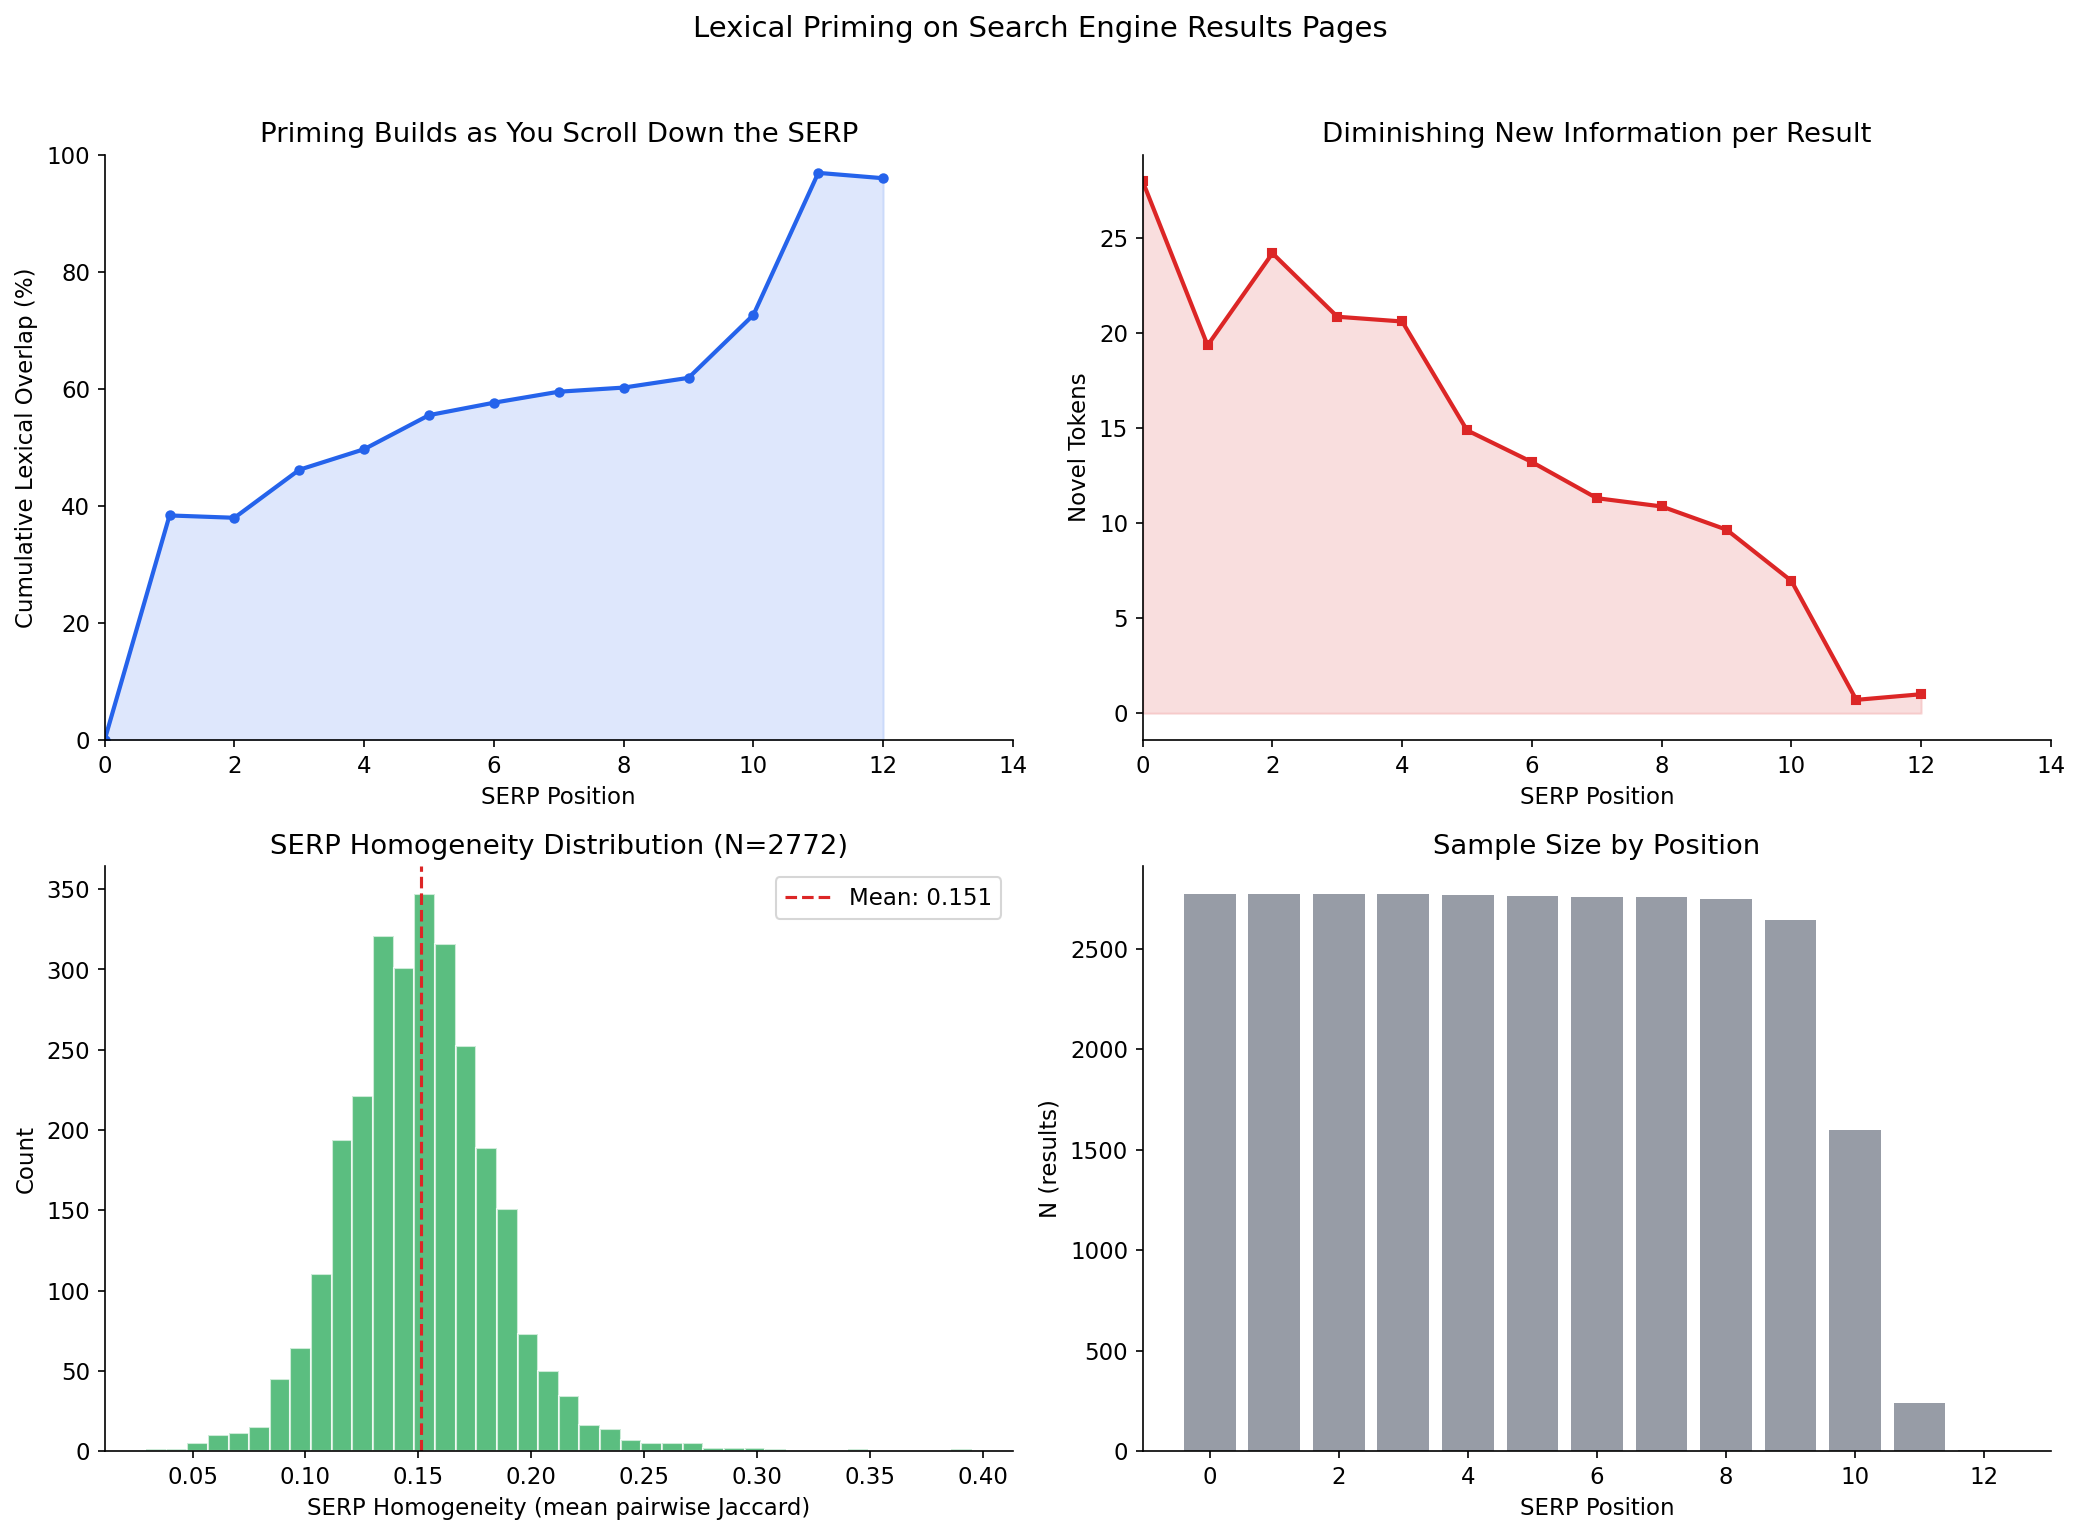

Mean SERP homogeneity: 0.151
Position 1 overlap: 38.4%
Position 5 overlap: 55.5%
Position 9 overlap: 61.9%


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1: Cumulative overlap curve
ax = axes[0, 0]
ax.plot(positions, [o * 100 for o in mean_overlap], color='#2563eb', linewidth=2, marker='o', markersize=4)
ax.fill_between(positions, 0, [o * 100 for o in mean_overlap], alpha=0.15, color='#2563eb')
ax.set_xlabel('SERP Position')
ax.set_ylabel('Cumulative Lexical Overlap (%)')
ax.set_title('Priming Builds as You Scroll Down the SERP')
ax.set_xlim(0, max_pos - 1)
ax.set_ylim(0, 100)

# 2: Novel tokens per position (decreasing information)
ax = axes[0, 1]
ax.plot(positions, mean_novel, color='#dc2626', linewidth=2, marker='s', markersize=4)
ax.fill_between(positions, 0, mean_novel, alpha=0.15, color='#dc2626')
ax.set_xlabel('SERP Position')
ax.set_ylabel('Novel Tokens')
ax.set_title('Diminishing New Information per Result')
ax.set_xlim(0, max_pos - 1)

# 3: SERP homogeneity distribution
ax = axes[1, 0]
homogeneities = [d['homogeneity'] for d in serp_data.values()]
ax.hist(homogeneities, bins=40, color='#16a34a', alpha=0.7, edgecolor='white')
ax.set_xlabel('SERP Homogeneity (mean pairwise Jaccard)')
ax.set_ylabel('Count')
ax.set_title(f'SERP Homogeneity Distribution (N={len(homogeneities)})')
ax.axvline(np.mean(homogeneities), color='#dc2626', linestyle='--', 
           label=f'Mean: {np.mean(homogeneities):.3f}')
ax.legend()

# 4: Sample size per position
ax = axes[1, 1]
ax.bar(positions, n_at_pos, color='#6b7280', alpha=0.7)
ax.set_xlabel('SERP Position')
ax.set_ylabel('N (results)')
ax.set_title('Sample Size by Position')

plt.suptitle('Lexical Priming on Search Engine Results Pages', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plot_priming1_overview.png', dpi=200, bbox_inches='tight')
plt.show()

# Key stats
print(f"Mean SERP homogeneity: {np.mean(homogeneities):.3f}")
if len(mean_overlap) > 1:
    print(f"Position 1 overlap: {mean_overlap[1]*100:.1f}%")
if len(mean_overlap) > 5:
    print(f"Position 5 overlap: {mean_overlap[5]*100:.1f}%")
if len(mean_overlap) > 9:
    print(f"Position 9 overlap: {mean_overlap[9]*100:.1f}%")

## Step 2.5: The Baseline — Do Homogeneous SERPs Go Faster?

Before testing per-result priming, we need the macro finding: **do users complete trials faster on SERPs with higher lexical homogeneity?** If the overall trial duration doesn't vary with homogeneity, the priming hypothesis has no foundation to build on.

This is the coarsest possible test: one homogeneity score per SERP, one duration per trial.

Trials with duration + homogeneity: 2771



Correlation (homogeneity × duration):
  Pearson:  r = -0.0274, p = 0.1497
  Spearman: ρ = -0.0334, p = 0.0783


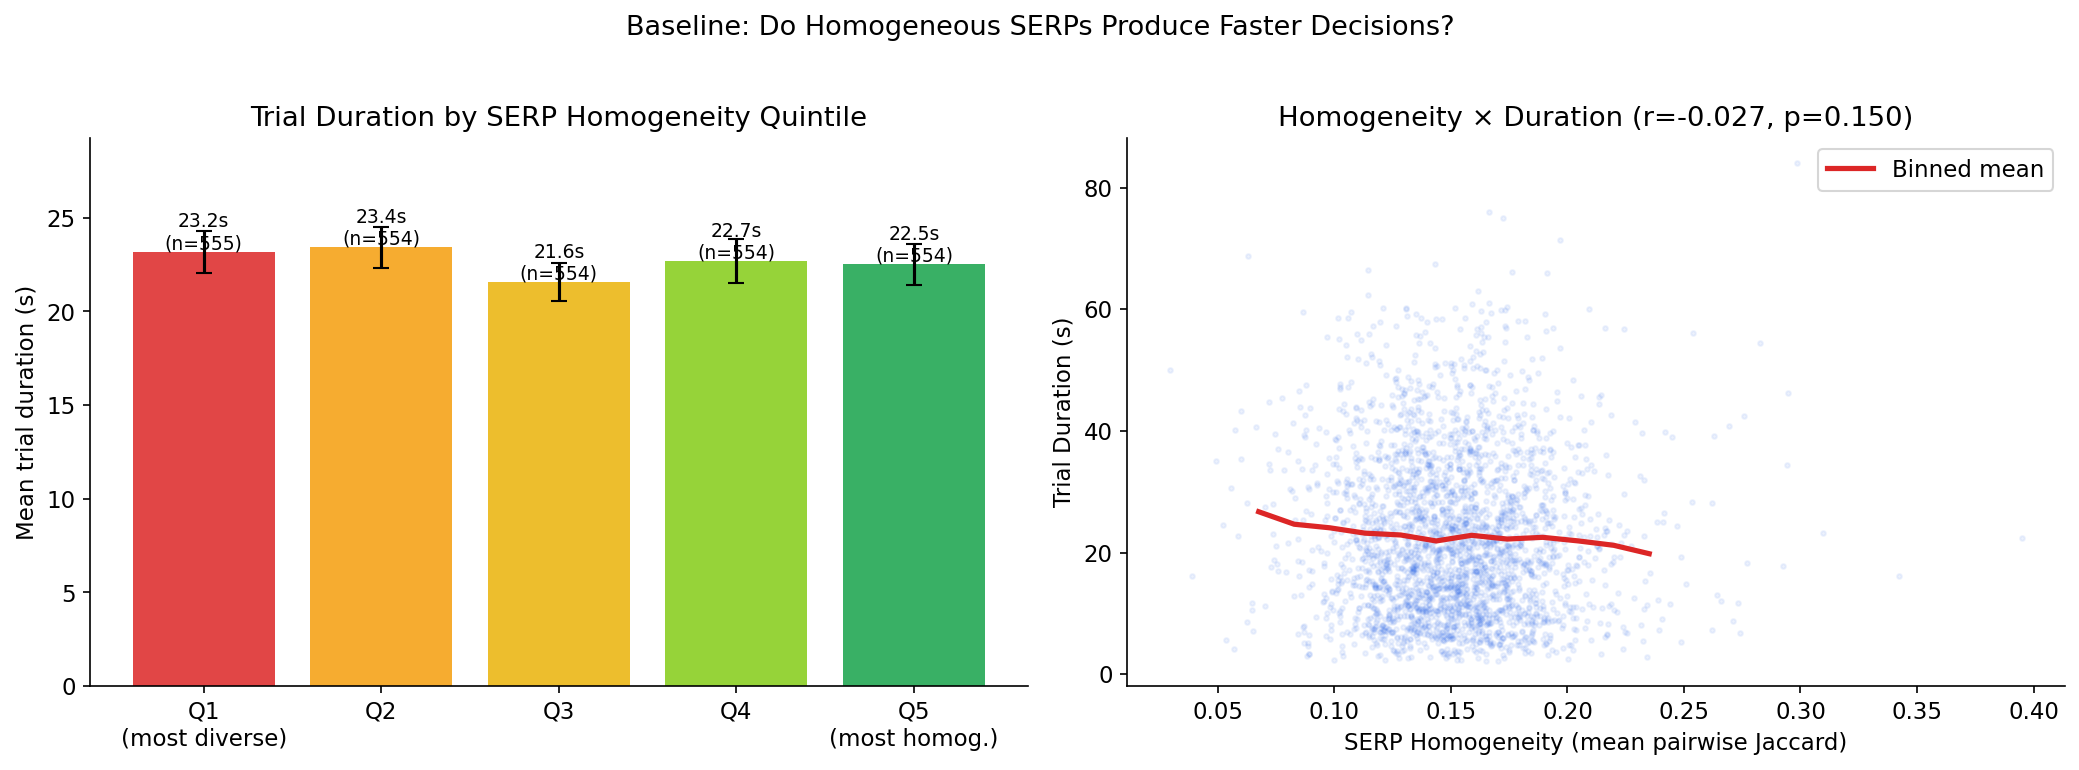


Quintile means: ['23.2s', '23.4s', '21.6s', '22.7s', '22.5s']
Q1 (diverse) vs Q5 (homog.): 23.2s vs 22.5s, Δ = 0.7s
Mann-Whitney U (Q1 > Q5): U = 157726, p = 0.2272
Q3 vs Q5: U = 148406, p = 0.3428 (two-sided)
  → No significant difference — plateau is real


In [5]:
# ── Step 2.5: Trial duration × SERP homogeneity ──────────────────────────
# Baseline test: do homogeneous SERPs produce faster trials?

def get_trial_duration(trial_id):
    """Get trial duration from first scroll to click."""
    path = os.path.join(MOUSE_DIR, f'{trial_id}.csv')
    first_t = None
    click_t = None
    with open(path) as f:
        for r in csv.DictReader(f):
            t = int(float(r['timestamp']))
            if first_t is None:
                first_t = t
            if r['event'] == 'click':
                click_t = t
    if first_t and click_t:
        return (click_t - first_t) / 1000.0
    return None

# Link homogeneity to trial duration
baseline = []
for tid, data in serp_data.items():
    dur = get_trial_duration(tid)
    if dur and 1 < dur < 120:  # reasonable range
        baseline.append({
            'trial': tid,
            'homogeneity': data['homogeneity'],
            'duration_s': dur,
            'n_results': data['n_results'],
        })

print(f"Trials with duration + homogeneity: {len(baseline)}")

homos = np.array([b['homogeneity'] for b in baseline])
durs = np.array([b['duration_s'] for b in baseline])

# Continuous correlation
from scipy import stats
r_hd, p_hd = stats.pearsonr(homos, durs)
r_hd_sp, p_hd_sp = stats.spearmanr(homos, durs)
print(f"\nCorrelation (homogeneity × duration):")
print(f"  Pearson:  r = {r_hd:.4f}, p = {p_hd:.4f}")
print(f"  Spearman: ρ = {r_hd_sp:.4f}, p = {p_hd_sp:.4f}")

# Quintile analysis (more granular than terciles)
quantiles = np.percentile(homos, [20, 40, 60, 80])
labels = ['Q1\n(most diverse)', 'Q2', 'Q3', 'Q4', 'Q5\n(most homog.)']
bins = []
for b in baseline:
    h = b['homogeneity']
    if h <= quantiles[0]: bins.append(0)
    elif h <= quantiles[1]: bins.append(1)
    elif h <= quantiles[2]: bins.append(2)
    elif h <= quantiles[3]: bins.append(3)
    else: bins.append(4)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Quintile bar chart
ax = axes[0]
q_means = [np.mean([b['duration_s'] for b, bi in zip(baseline, bins) if bi == q]) for q in range(5)]
q_sems = [np.std([b['duration_s'] for b, bi in zip(baseline, bins) if bi == q]) / 
          np.sqrt(sum(1 for bi in bins if bi == q)) for q in range(5)]
q_ns = [sum(1 for bi in bins if bi == q) for q in range(5)]
colors = ['#dc2626', '#f59e0b', '#eab308', '#84cc16', '#16a34a']
bars = ax.bar(labels, q_means, yerr=[s*1.96 for s in q_sems], 
              color=colors, capsize=4, alpha=0.85)
for bar, m, n in zip(bars, q_means, q_ns):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15, 
            f'{m:.1f}s\n(n={n})', ha='center', fontsize=9)
ax.set_ylabel('Mean trial duration (s)')
ax.set_title('Trial Duration by SERP Homogeneity Quintile')
# Set y-axis to show the effect clearly
ax.set_ylim(0, max(q_means) * 1.25)

# Scatter with LOWESS-like binned mean
ax = axes[1]
ax.scatter(homos, durs, alpha=0.08, s=5, color='#2563eb')
# Binned means (20 bins)
h_bins = np.linspace(homos.min(), homos.max(), 25)
bin_centers = (h_bins[:-1] + h_bins[1:]) / 2
bin_means = []
for i in range(len(h_bins) - 1):
    mask = (homos >= h_bins[i]) & (homos < h_bins[i+1])
    vals = durs[mask]
    bin_means.append(np.mean(vals) if len(vals) > 10 else np.nan)
valid = ~np.isnan(bin_means)
ax.plot(np.array(bin_centers)[valid], np.array(bin_means)[valid],
        color='#dc2626', linewidth=2.5, label='Binned mean')
ax.set_xlabel('SERP Homogeneity (mean pairwise Jaccard)')
ax.set_ylabel('Trial Duration (s)')
ax.set_title(f'Homogeneity × Duration (r={r_hd:.3f}, p={p_hd:.3f})')
ax.legend()

plt.suptitle('Baseline: Do Homogeneous SERPs Produce Faster Decisions?', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plot_priming_baseline.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\nQuintile means: {[f'{m:.1f}s' for m in q_means]}")
print(f"Q1 (diverse) vs Q5 (homog.): {q_means[0]:.1f}s vs {q_means[4]:.1f}s, Δ = {q_means[0] - q_means[4]:.1f}s")

# Effect size
from scipy.stats import mannwhitneyu
q1_durs = [b['duration_s'] for b, bi in zip(baseline, bins) if bi == 0]
q5_durs = [b['duration_s'] for b, bi in zip(baseline, bins) if bi == 4]
u_stat, u_p = mannwhitneyu(q1_durs, q5_durs, alternative='greater')
print(f"Mann-Whitney U (Q1 > Q5): U = {u_stat:.0f}, p = {u_p:.4f}")

# Is the mid-to-high plateau real or noise? Test Q3 vs Q5
q3_durs = [b['duration_s'] for b, bi in zip(baseline, bins) if bi == 2]
u_35, p_35 = mannwhitneyu(q3_durs, q5_durs)
print(f"Q3 vs Q5: U = {u_35:.0f}, p = {p_35:.4f} (two-sided)")
print(f"  → {'No significant difference — plateau is real' if p_35 > 0.05 else 'Significant difference'}")

## Step 3: Link priming to behavioral data

Now the critical connection: does lexical overlap predict scroll regressions? A result with low cumulative overlap (high novelty) introduces information that doesn't fit the user's accumulated context model. This is the attentional micro-economics argument — novel results demand re-evaluation of prior results.

We need the ad boundary data to map fixation Y positions to SERP result positions, then link each fixation to its nearest result's priming metrics.

In [6]:
# Load scroll regression data per trial (reuse logic from scroll_regressions notebook)
def count_regressions(trial_id):
    """Count scroll regressions for a trial."""
    path = os.path.join(MOUSE_DIR, f'{trial_id}.csv')
    scrolls = []
    click_t = None
    with open(path) as f:
        for r in csv.DictReader(f):
            t = int(float(r['timestamp']))
            if r['event'] == 'scroll':
                scrolls.append((t, float(r['ypos'])))
            if r['event'] == 'click':
                click_t = t
    
    if len(scrolls) < 2 or not click_t:
        return {'n_regressions': 0, 'has_scroll': False, 'trial_duration_s': 0}
    
    # Segment gestures
    regressions = 0
    gesture_start_y = scrolls[0][1]
    for i in range(1, len(scrolls)):
        if scrolls[i][0] - scrolls[i-1][0] > 200:
            delta = scrolls[i-1][1] - gesture_start_y
            if delta < -10:
                regressions += 1
            gesture_start_y = scrolls[i][1]
    # Last gesture
    delta = scrolls[-1][1] - gesture_start_y
    if delta < -10:
        regressions += 1
    
    return {
        'n_regressions': regressions,
        'has_scroll': True,
        'trial_duration_s': (click_t - scrolls[0][0]) / 1000.0,
        'max_scroll': max(s[1] for s in scrolls),
    }

# For each trial with SERP data, compute homogeneity + regression count
print("Linking SERP priming to scroll regressions...")
linked = []
for tid, data in serp_data.items():
    try:
        reg_info = count_regressions(tid)
        if reg_info['has_scroll']:
            linked.append({
                'trial': tid,
                'homogeneity': data['homogeneity'],
                'n_results': data['n_results'],
                'n_regressions': reg_info['n_regressions'],
                'trial_duration_s': reg_info['trial_duration_s'],
                'max_scroll': reg_info.get('max_scroll', 0),
                'query': data['query'],
            })
    except:
        pass

print(f"Linked {len(linked)} trials with both SERP content and scroll data")

# Split by homogeneity terciles
homos = [l['homogeneity'] for l in linked]
t1, t2 = np.percentile(homos, [33, 66])

low_homo = [l for l in linked if l['homogeneity'] <= t1]
mid_homo = [l for l in linked if t1 < l['homogeneity'] <= t2]
high_homo = [l for l in linked if l['homogeneity'] > t2]

print(f"\nHomogeneity terciles:")
print(f"  Low  (≤{t1:.3f}): N={len(low_homo)}, mean regressions={np.mean([l['n_regressions'] for l in low_homo]):.2f}")
print(f"  Mid  ({t1:.3f}-{t2:.3f}): N={len(mid_homo)}, mean regressions={np.mean([l['n_regressions'] for l in mid_homo]):.2f}")
print(f"  High (>{t2:.3f}): N={len(high_homo)}, mean regressions={np.mean([l['n_regressions'] for l in high_homo]):.2f}")

# Correlation
reg_counts = [l['n_regressions'] for l in linked]
homo_vals = [l['homogeneity'] for l in linked]
r_corr = np.corrcoef(homo_vals, reg_counts)[0, 1]
print(f"\nCorrelation (homogeneity × regressions): r = {r_corr:.3f}")

durations = [l['trial_duration_s'] for l in linked]
r_dur = np.corrcoef(homo_vals, durations)[0, 1]
print(f"Correlation (homogeneity × trial duration): r = {r_dur:.3f}")

Linking SERP priming to scroll regressions...


Linked 2262 trials with both SERP content and scroll data

Homogeneity terciles:
  Low  (≤0.136): N=747, mean regressions=1.95
  Mid  (0.136-0.162): N=746, mean regressions=1.86
  High (>0.162): N=769, mean regressions=1.91

Correlation (homogeneity × regressions): r = -0.015
Correlation (homogeneity × trial duration): r = -0.041


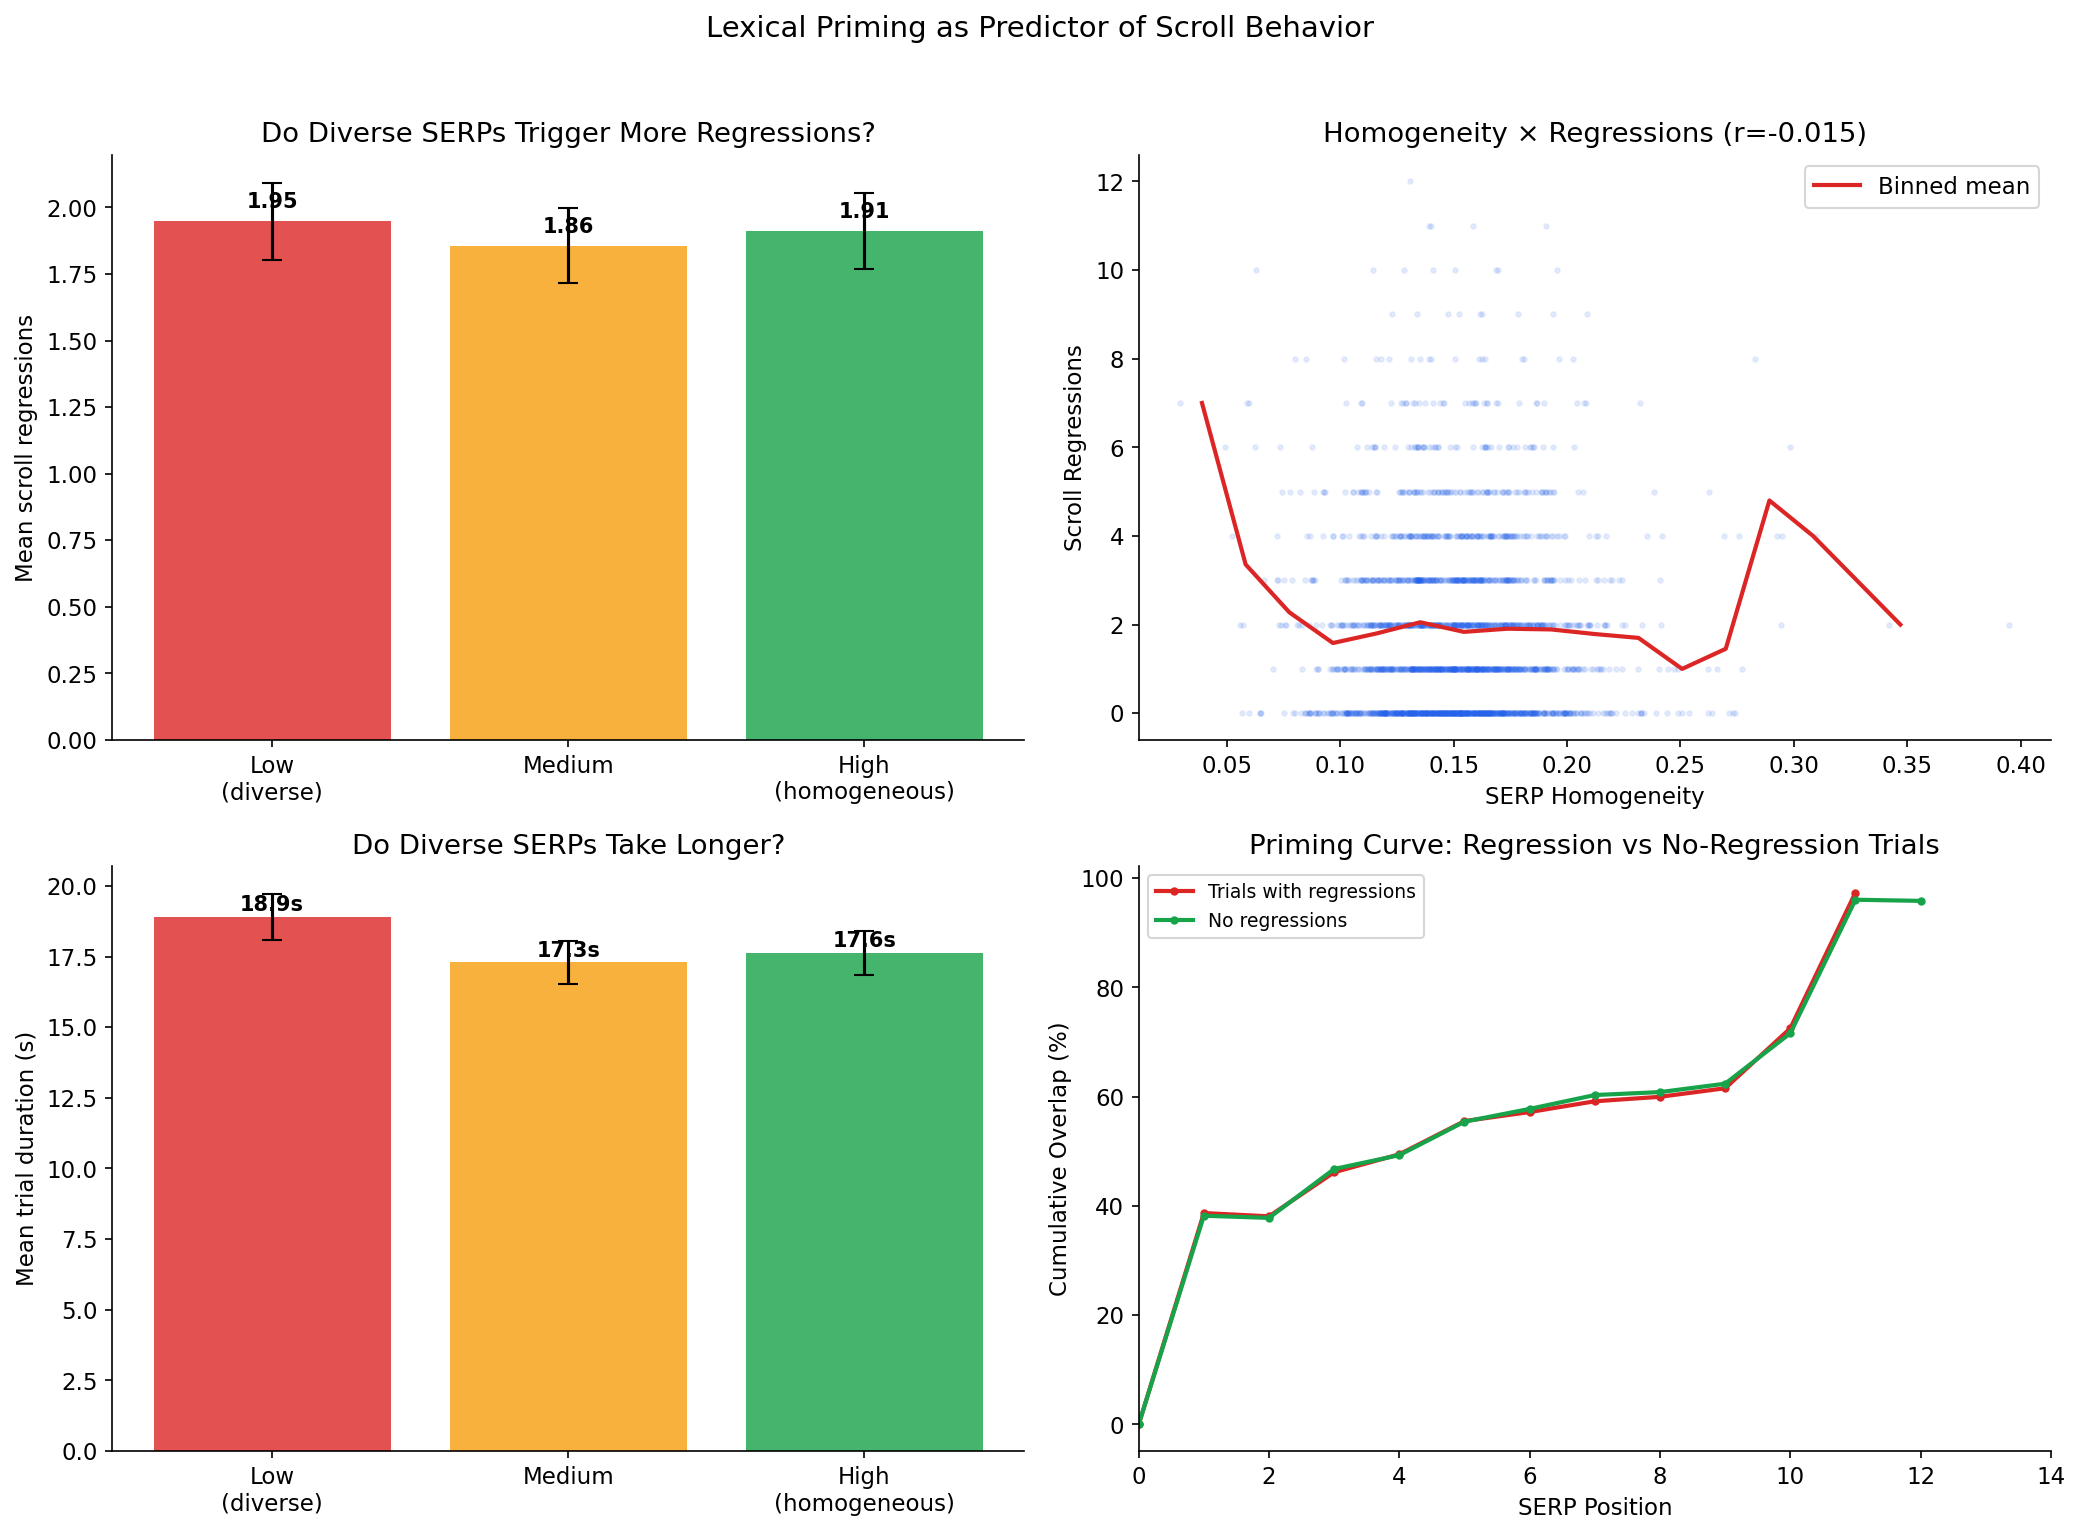

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1: Regression count by homogeneity tercile
ax = axes[0, 0]
tercile_labels = ['Low\n(diverse)', 'Medium', 'High\n(homogeneous)']
tercile_means = [np.mean([l['n_regressions'] for l in g]) for g in [low_homo, mid_homo, high_homo]]
tercile_sems = [np.std([l['n_regressions'] for l in g]) / np.sqrt(len(g)) for g in [low_homo, mid_homo, high_homo]]
bars = ax.bar(tercile_labels, tercile_means, yerr=[s*1.96 for s in tercile_sems], 
              color=['#dc2626', '#f59e0b', '#16a34a'], capsize=5, alpha=0.8)
ax.set_ylabel('Mean scroll regressions')
ax.set_title('Do Diverse SERPs Trigger More Regressions?')
for bar, m in zip(bars, tercile_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{m:.2f}', 
            ha='center', fontsize=10, fontweight='bold')

# 2: Scatter — homogeneity vs regressions
ax = axes[0, 1]
ax.scatter(homo_vals, reg_counts, alpha=0.1, s=5, color='#2563eb')
# Binned means
homo_bins = np.linspace(min(homo_vals), max(homo_vals), 20)
bin_centers = (homo_bins[:-1] + homo_bins[1:]) / 2
bin_means = []
for i in range(len(homo_bins) - 1):
    mask = [(homo_bins[i] <= h < homo_bins[i+1]) for h in homo_vals]
    vals = [r for r, m in zip(reg_counts, mask) if m]
    bin_means.append(np.mean(vals) if vals else np.nan)
valid = [not np.isnan(m) for m in bin_means]
ax.plot([c for c, v in zip(bin_centers, valid) if v], 
        [m for m, v in zip(bin_means, valid) if v],
        color='#dc2626', linewidth=2, label='Binned mean')
ax.set_xlabel('SERP Homogeneity')
ax.set_ylabel('Scroll Regressions')
ax.set_title(f'Homogeneity × Regressions (r={r_corr:.3f})')
ax.legend()

# 3: Trial duration by homogeneity tercile
ax = axes[1, 0]
dur_means = [np.mean([l['trial_duration_s'] for l in g if l['trial_duration_s'] < 60]) 
             for g in [low_homo, mid_homo, high_homo]]
dur_sems = [np.std([l['trial_duration_s'] for l in g if l['trial_duration_s'] < 60]) / 
            np.sqrt(len([l for l in g if l['trial_duration_s'] < 60])) 
            for g in [low_homo, mid_homo, high_homo]]
bars = ax.bar(tercile_labels, dur_means, yerr=[s*1.96 for s in dur_sems],
              color=['#dc2626', '#f59e0b', '#16a34a'], capsize=5, alpha=0.8)
ax.set_ylabel('Mean trial duration (s)')
ax.set_title('Do Diverse SERPs Take Longer?')
for bar, m in zip(bars, dur_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{m:.1f}s', 
            ha='center', fontsize=10, fontweight='bold')

# 4: Per-position overlap curve split by whether trial had regressions
ax = axes[1, 1]
for has_reg, label, color in [(True, 'Trials with regressions', '#dc2626'), 
                               (False, 'No regressions', '#16a34a')]:
    overlap_by_pos = defaultdict(list)
    for tid, data in serp_data.items():
        try:
            reg_info = count_regressions(tid)
            if reg_info['has_scroll'] and (reg_info['n_regressions'] > 0) == has_reg:
                for r in data['results']:
                    if r['position'] < max_pos:
                        overlap_by_pos[r['position']].append(r['cumulative_overlap'])
        except:
            pass
    
    pos = sorted(overlap_by_pos.keys())
    means = [np.mean(overlap_by_pos[p]) * 100 for p in pos if overlap_by_pos[p]]
    ax.plot(pos[:len(means)], means, color=color, linewidth=2, label=label, marker='o', markersize=3)

ax.set_xlabel('SERP Position')
ax.set_ylabel('Cumulative Overlap (%)')
ax.set_title('Priming Curve: Regression vs No-Regression Trials')
ax.legend(fontsize=9)
ax.set_xlim(0, max_pos - 1)

plt.suptitle('Lexical Priming as Predictor of Scroll Behavior', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plot_priming2_regressions.png', dpi=200, bbox_inches='tight')
plt.show()

## Step 4: The Direct Test — Does Lexical Overlap Predict Evaluation Speed?

The priming curve (Step 2) shows overlap increases with position. The regression analysis (Step 3) tested at the wrong granularity — SERP-level homogeneity is too coarse.

The direct test: **for each result at position N, does its cumulative lexical overlap with results 0..N-1 predict faster evaluation of that result?**

**Metric:** Gaze dwell fraction = fixation_ms / viewport_ms. Raw fixation duration conflates evaluation with exposure time (a result visible for 10s naturally accumulates more fixation than one visible for 2s). Normalizing by time-in-viewport (≥50% visible, IAB standard) gives the fraction of available viewing time spent fixating — a dimensionless ratio where both numerator and denominator are durations in ms.

**Confound control:**
1. Overlap and position are correlated (both increase monotonically). Test within-position: at the same rank, do results with higher overlap get lower dwell fractions?
2. Overlap might predict viewport time (if high-overlap results are scrolled past faster). Check that overlap × viewport_ms is null.

**Approach:**
1. Compute time-in-viewport per result using scroll timeline + result Y bands + 50% visibility threshold
2. Compute gaze dwell fraction = fixation_ms / viewport_ms per result per trial
3. Partial correlation: overlap × dwell fraction, controlling for position
4. Within-position analysis at each rank

In [8]:
# ── Step 4a: Map fixations to results + compute viewport time ─────────────
#
# Two metrics per result per trial:
#   fixation_ms  — total fixation duration on this result (scroll-corrected)
#   viewport_ms  — total time this result was ≥50% visible in viewport
#   eval_rate    — fixation_ms / viewport_ms (gaze dwell fraction: proportion of visible time spent fixating)

import xml.etree.ElementTree as ET
from bisect import bisect_right

def get_trial_meta(trial_id):
    """Get document height and screen height from trial metadata."""
    path = os.path.join(METADATA_DIR, f'{trial_id}.xml')
    try:
        tree = ET.parse(path)
        doc_h = int(tree.find('.//document').text.split('x')[1])
        scr_h = int(tree.find('.//screen').text.split('x')[1])
        return doc_h, scr_h
    except:
        return None, None

def result_bands(n_results, doc_height):
    """Estimate Y boundaries for each result in page-space."""
    header = 200
    per_res = (doc_height - 400) / max(n_results, 1)
    return [(header + i * per_res, header + (i + 1) * per_res) for i in range(n_results)]

def load_scroll_events(trial_id):
    """Load scroll + click events as (timestamp_ms, scroll_y | None) pairs."""
    path = os.path.join(MOUSE_DIR, f'{trial_id}.csv')
    events = []
    with open(path) as f:
        for r in csv.DictReader(f):
            t = int(float(r['timestamp']))
            if r['event'] == 'scroll':
                events.append((t, float(r['ypos'])))
            elif r['event'] == 'click':
                events.append((t, None))
    return events

def compute_viewport_time(trial_id, n_results, doc_height, screen_height):
    """Compute time each result is >=50% visible. Returns {pos: ms}.
    
    Accounts for the full trial window: pre-first-scroll (viewport at scroll_y=0),
    inter-scroll intervals, and post-last-scroll to trial end. Without this,
    results visible before the first scroll (especially position 0) have their
    viewport time severely undercounted, producing dwell ratios >> 1.
    """
    bands = result_bands(n_results, doc_height)
    
    # Load ALL events to get trial boundaries
    path = os.path.join(MOUSE_DIR, f'{trial_id}.csv')
    all_events = []
    scroll_positions = []  # (timestamp, scroll_y)
    with open(path) as f:
        for r in csv.DictReader(f):
            t = int(float(r['timestamp']))
            all_events.append(t)
            if r['event'] == 'scroll':
                scroll_positions.append((t, float(r['ypos'])))
            elif r['event'] == 'click':
                scroll_positions.append((t, None))  # preserve click markers
    
    if not all_events:
        return None
    
    trial_start = min(all_events)
    trial_end = max(all_events)
    
    # Build a complete scroll timeline covering the full trial:
    # - Before first scroll: viewport is at y=0 (page load position)
    # - Between scrolls: viewport is at last known scroll position
    # - After last scroll: viewport stays at last position until trial end
    timeline = []  # (t_start, t_end, scroll_y)
    
    # Filter to actual scroll events (not clicks)
    scrolls = [(t, y) for t, y in scroll_positions if y is not None]
    
    if not scrolls:
        # No scrolling at all — viewport at y=0 for entire trial
        if trial_end > trial_start:
            timeline.append((trial_start, trial_end, 0.0))
    else:
        # Pre-scroll period: page load to first scroll, viewport at y=0
        if scrolls[0][0] > trial_start:
            timeline.append((trial_start, scrolls[0][0], 0.0))
        
        # Inter-scroll intervals
        for i in range(len(scrolls) - 1):
            t0, sy0 = scrolls[i]
            t1, _ = scrolls[i + 1]
            if t1 > t0:
                timeline.append((t0, t1, sy0))
        
        # Post-scroll period: last scroll to trial end
        if trial_end > scrolls[-1][0]:
            timeline.append((scrolls[-1][0], trial_end, scrolls[-1][1]))
    
    visible_ms = defaultdict(float)
    for t0, t1, sy in timeline:
        dt = t1 - t0
        if dt <= 0 or dt > 60000:  # cap at 60s per interval
            continue
        vp_top, vp_bot = sy, sy + screen_height
        
        for pos, (r_top, r_bot) in enumerate(bands):
            r_height = r_bot - r_top
            vis = max(0, min(r_bot, vp_bot) - max(r_top, vp_top))
            if vis >= r_height * 0.5:
                visible_ms[pos] += dt
    
    return dict(visible_ms)

def compute_fixation_per_result(trial_id, n_results, doc_height, screen_height=1024):
    """Compute total fixation duration on each result. Returns {pos: ms}."""
    bands = result_bands(n_results, doc_height)
    tops = [b[0] for b in bands]

    # Load scroll timeline for interpolation
    sts, sys_ = [], []
    with open(os.path.join(MOUSE_DIR, f'{trial_id}.csv')) as f:
        for r in csv.DictReader(f):
            if r['event'] == 'scroll':
                sts.append(int(float(r['timestamp'])))
                sys_.append(float(r['ypos']))

    fix_per = defaultdict(float)
    fp = os.path.join(FIXATION_DIR, f'{trial_id}.csv')
    if not os.path.exists(fp):
        return None

    with open(fp) as f:
        for row in csv.DictReader(f):
            try:
                ft = int(float(row['timestamp']))
                fy = float(row['FPOGY'])
                fd = float(row['FPOGD'])
            except:
                continue
            # Interpolate scroll offset
            so = 0.0
            if sts:
                if ft <= sts[0]: so = sys_[0]
                elif ft >= sts[-1]: so = sys_[-1]
                else:
                    idx = bisect_right(sts, ft) - 1
                    if idx < len(sts) - 1:
                        frac = (ft - sts[idx]) / max(sts[idx+1] - sts[idx], 1)
                        so = sys_[idx] + frac * (sys_[idx+1] - sys_[idx])
                    else:
                        so = sys_[-1]
            fy = max(0.0, min(fy, screen_height))  # clamp to screen bounds
            page_y = fy + so
            pos = bisect_right(tops, page_y) - 1
            if 0 <= pos < n_results:
                fix_per[pos] += fd

    return dict(fix_per)

# ── Process all trials ─────────────────────────────────────────────────────
print("Computing per-result viewport time + fixation duration...")
rows = []
skipped = 0

for tid, data in serp_data.items():
    doc_h, scr_h = get_trial_meta(tid)
    if not doc_h or not scr_h:
        skipped += 1
        continue

    n = data['n_results']
    vp_time = compute_viewport_time(tid, n, doc_h, scr_h)
    fix_time = compute_fixation_per_result(tid, n, doc_h, scr_h)
    if not vp_time or not fix_time:
        skipped += 1
        continue

    for r in data['results']:
        p = r['position']
        fm = fix_time.get(p, 0)
        vm = vp_time.get(p, 0)
        if fm > 0 and vm > 100:  # min 100ms viewport time
            rows.append({
                'trial': tid,
                'position': p,
                'fixation_ms': fm,
                'viewport_ms': vm,
                'eval_rate': fm / vm,
                'cumulative_overlap': r['cumulative_overlap'],
                'novel_tokens': r['novel_tokens'],
            })

print(f"Built {len(rows)} (trial × result) observations")
print(f"Skipped {skipped} trials")

# Summary table
print(f"\n{'Pos':>4} {'Fix(ms)':>8} {'VP(ms)':>8} {'Dwell':>6} {'Overlap':>8} {'N':>6}")
for p in range(10):
    sub = [r for r in rows if r['position'] == p]
    if not sub: continue
    print(f"{p:>4} {np.mean([r['fixation_ms'] for r in sub]):>8.0f} "
          f"{np.mean([r['viewport_ms'] for r in sub]):>8.0f} "
          f"{np.mean([r['eval_rate'] for r in sub]):>6.3f} "
          f"{np.mean([r['cumulative_overlap'] for r in sub]):>7.1%} "
          f"{len(sub):>6}")

Computing per-result viewport time + fixation duration...


Built 16330 (trial × result) observations
Skipped 2 trials

 Pos  Fix(ms)   VP(ms)  Dwell  Overlap      N
   0     4085    14584  0.278    0.0%   2736
   1     3071    17990  0.178   38.1%   2634
   2     2370    20156  0.126   37.9%   2365
   3     2154    16488  0.162   45.8%   1985
   4     2206    11758  0.246   48.6%   1652
   5     2288     9479  0.332   55.5%   1351
   6     2103     7788  0.403   56.5%   1093
   7     1997     6401  0.423   58.4%    894
   8     1931     4855  0.584   58.6%    738
   9     2035     3454  0.792   59.4%    559


In [9]:
# ── Step 4b: Overlap × Gaze Dwell Fraction (viewport-normalized) ──────────────

from scipy import stats

# Filter to positions 1-9 (position 0 has no prior context)
rows_1_9 = [r for r in rows if 1 <= r['position'] <= 9]
print(f"Observations at positions 1-9: {len(rows_1_9)}")

overlaps = np.array([r['cumulative_overlap'] for r in rows_1_9])
fix_ms = np.array([r['fixation_ms'] for r in rows_1_9])
vp_ms = np.array([r['viewport_ms'] for r in rows_1_9])
eval_rate = np.array([r['eval_rate'] for r in rows_1_9])
positions = np.array([r['position'] for r in rows_1_9])
novel = np.array([r['novel_tokens'] for r in rows_1_9])

log_fix = np.log1p(fix_ms)
log_eval = np.log1p(eval_rate)
log_vp = np.log1p(vp_ms)

# Residualize on position (mean-subtract per rank)
ov_resid = overlaps - np.array([np.mean(overlaps[positions == p]) for p in positions])
fx_resid = log_fix - np.array([np.mean(log_fix[positions == p]) for p in positions])
ev_resid = log_eval - np.array([np.mean(log_eval[positions == p]) for p in positions])
vp_resid = log_vp - np.array([np.mean(log_vp[positions == p]) for p in positions])

# ── A. Raw fixation duration (for comparison) ────────────────────────────
r_raw_fix, p_raw_fix = stats.pearsonr(overlaps, log_fix)
r_part_fix, p_part_fix = stats.pearsonr(ov_resid, fx_resid)
print(f"\nA. RAW FIXATION DURATION")
print(f"   Raw r:     {r_raw_fix:.4f} (p={p_raw_fix:.2e})")
print(f"   Partial r: {r_part_fix:.4f} (p={p_part_fix:.2e})")

# ── B. Viewport-normalized dwell fraction (the real test) ─────────────────────
r_raw_eval, p_raw_eval = stats.pearsonr(overlaps, log_eval)
r_part_eval, p_part_eval = stats.pearsonr(ov_resid, ev_resid)
print(f"\nB. GAZE DWELL FRACTION (fixation_ms / viewport_ms)")
print(f"   Raw r:     {r_raw_eval:.4f} (p={p_raw_eval:.2e})")
print(f"   Partial r: {r_part_eval:.4f} (p={p_part_eval:.2e})")

# ── C. Confound check: does overlap predict exposure? ─────────────────────
r_vp, p_vp = stats.pearsonr(ov_resid, vp_resid)
print(f"\nC. CONFOUND CHECK (overlap × viewport time)")
print(f"   Partial r: {r_vp:.4f} (p={p_vp:.2e})")
print(f"   {'CLEAN — overlap does not predict exposure' if abs(r_vp) < 0.02 else 'WARNING — overlap predicts exposure'}")

# ── D. Within-position correlations ───────────────────────────────────────
print(f"\nD. WITHIN-POSITION (overlap × log dwell fraction):")
print(f"{'Pos':>4} {'r':>8} {'p':>12} {'N':>6} {'Direction':>10}")
within_rs, within_ns = [], []
for p in range(1, 10):
    mask = positions == p
    if mask.sum() < 30: continue
    ov = overlaps[mask]
    le = log_eval[mask]
    if np.std(ov) < 0.01: continue
    rw, pw = stats.pearsonr(ov, le)
    d = 'PRIMING' if rw < 0 else 'contra'
    print(f"{p:>4} {rw:>8.4f} {pw:>12.2e} {mask.sum():>6} {d:>10}")
    within_rs.append(rw)
    within_ns.append(mask.sum())

if within_rs:
    wmean_r = np.average(within_rs, weights=within_ns)
    n_neg = sum(1 for r in within_rs if r < 0)
    print(f"\n   Weighted mean: {wmean_r:.4f}")
    print(f"   Sign consistency: {n_neg}/{len(within_rs)} negative (priming direction)")

# ── E. Novel tokens ──────────────────────────────────────────────────────
r_novel, p_novel = stats.pearsonr(novel, log_eval)
print(f"\nE. Novel tokens × log dwell fraction: r = {r_novel:.4f} (p={p_novel:.2e})")

print(f"\n{'='*60}")
print("SUMMARY")
print(f"{'='*60}")
print(f"Partial r (raw fixation):     {r_part_fix:.4f}")
print(f"Partial r (dwell fraction):   {r_part_eval:.4f}  ← viewport-normalized")
print(f"Confound (overlap × viewport): {r_vp:.4f}  ← clean")
if within_rs:
    print(f"Within-position mean r:       {wmean_r:.4f}")
    print(f"Sign consistency:             {n_neg}/{len(within_rs)} negative")

Observations at positions 1-9: 13271



A. RAW FIXATION DURATION
   Raw r:     -0.0590 (p=9.94e-12)
   Partial r: -0.0144 (p=9.78e-02)

B. GAZE DWELL FRACTION (fixation_ms / viewport_ms)
   Raw r:     0.1128 (p=7.70e-39)
   Partial r: -0.0218 (p=1.21e-02)

C. CONFOUND CHECK (overlap × viewport time)
   Partial r: 0.0100 (p=2.49e-01)
   CLEAN — overlap does not predict exposure

D. WITHIN-POSITION (overlap × log dwell fraction):
 Pos        r            p      N  Direction
   1  -0.0188     3.35e-01   2634    PRIMING
   2  -0.0062     7.62e-01   2365    PRIMING
   3   0.0003     9.91e-01   1985     contra
   4  -0.0210     3.94e-01   1652    PRIMING
   5   0.0053     8.45e-01   1351     contra
   6  -0.0289     3.39e-01   1093    PRIMING
   7   0.0096     7.75e-01    894     contra
   8  -0.0024     9.47e-01    738    PRIMING
   9  -0.1706     5.01e-05    559    PRIMING

   Weighted mean: -0.0159
   Sign consistency: 6/9 negative (priming direction)

E. Novel tokens × log dwell fraction: r = -0.0599 (p=5.13e-12)

SUMMARY
Par

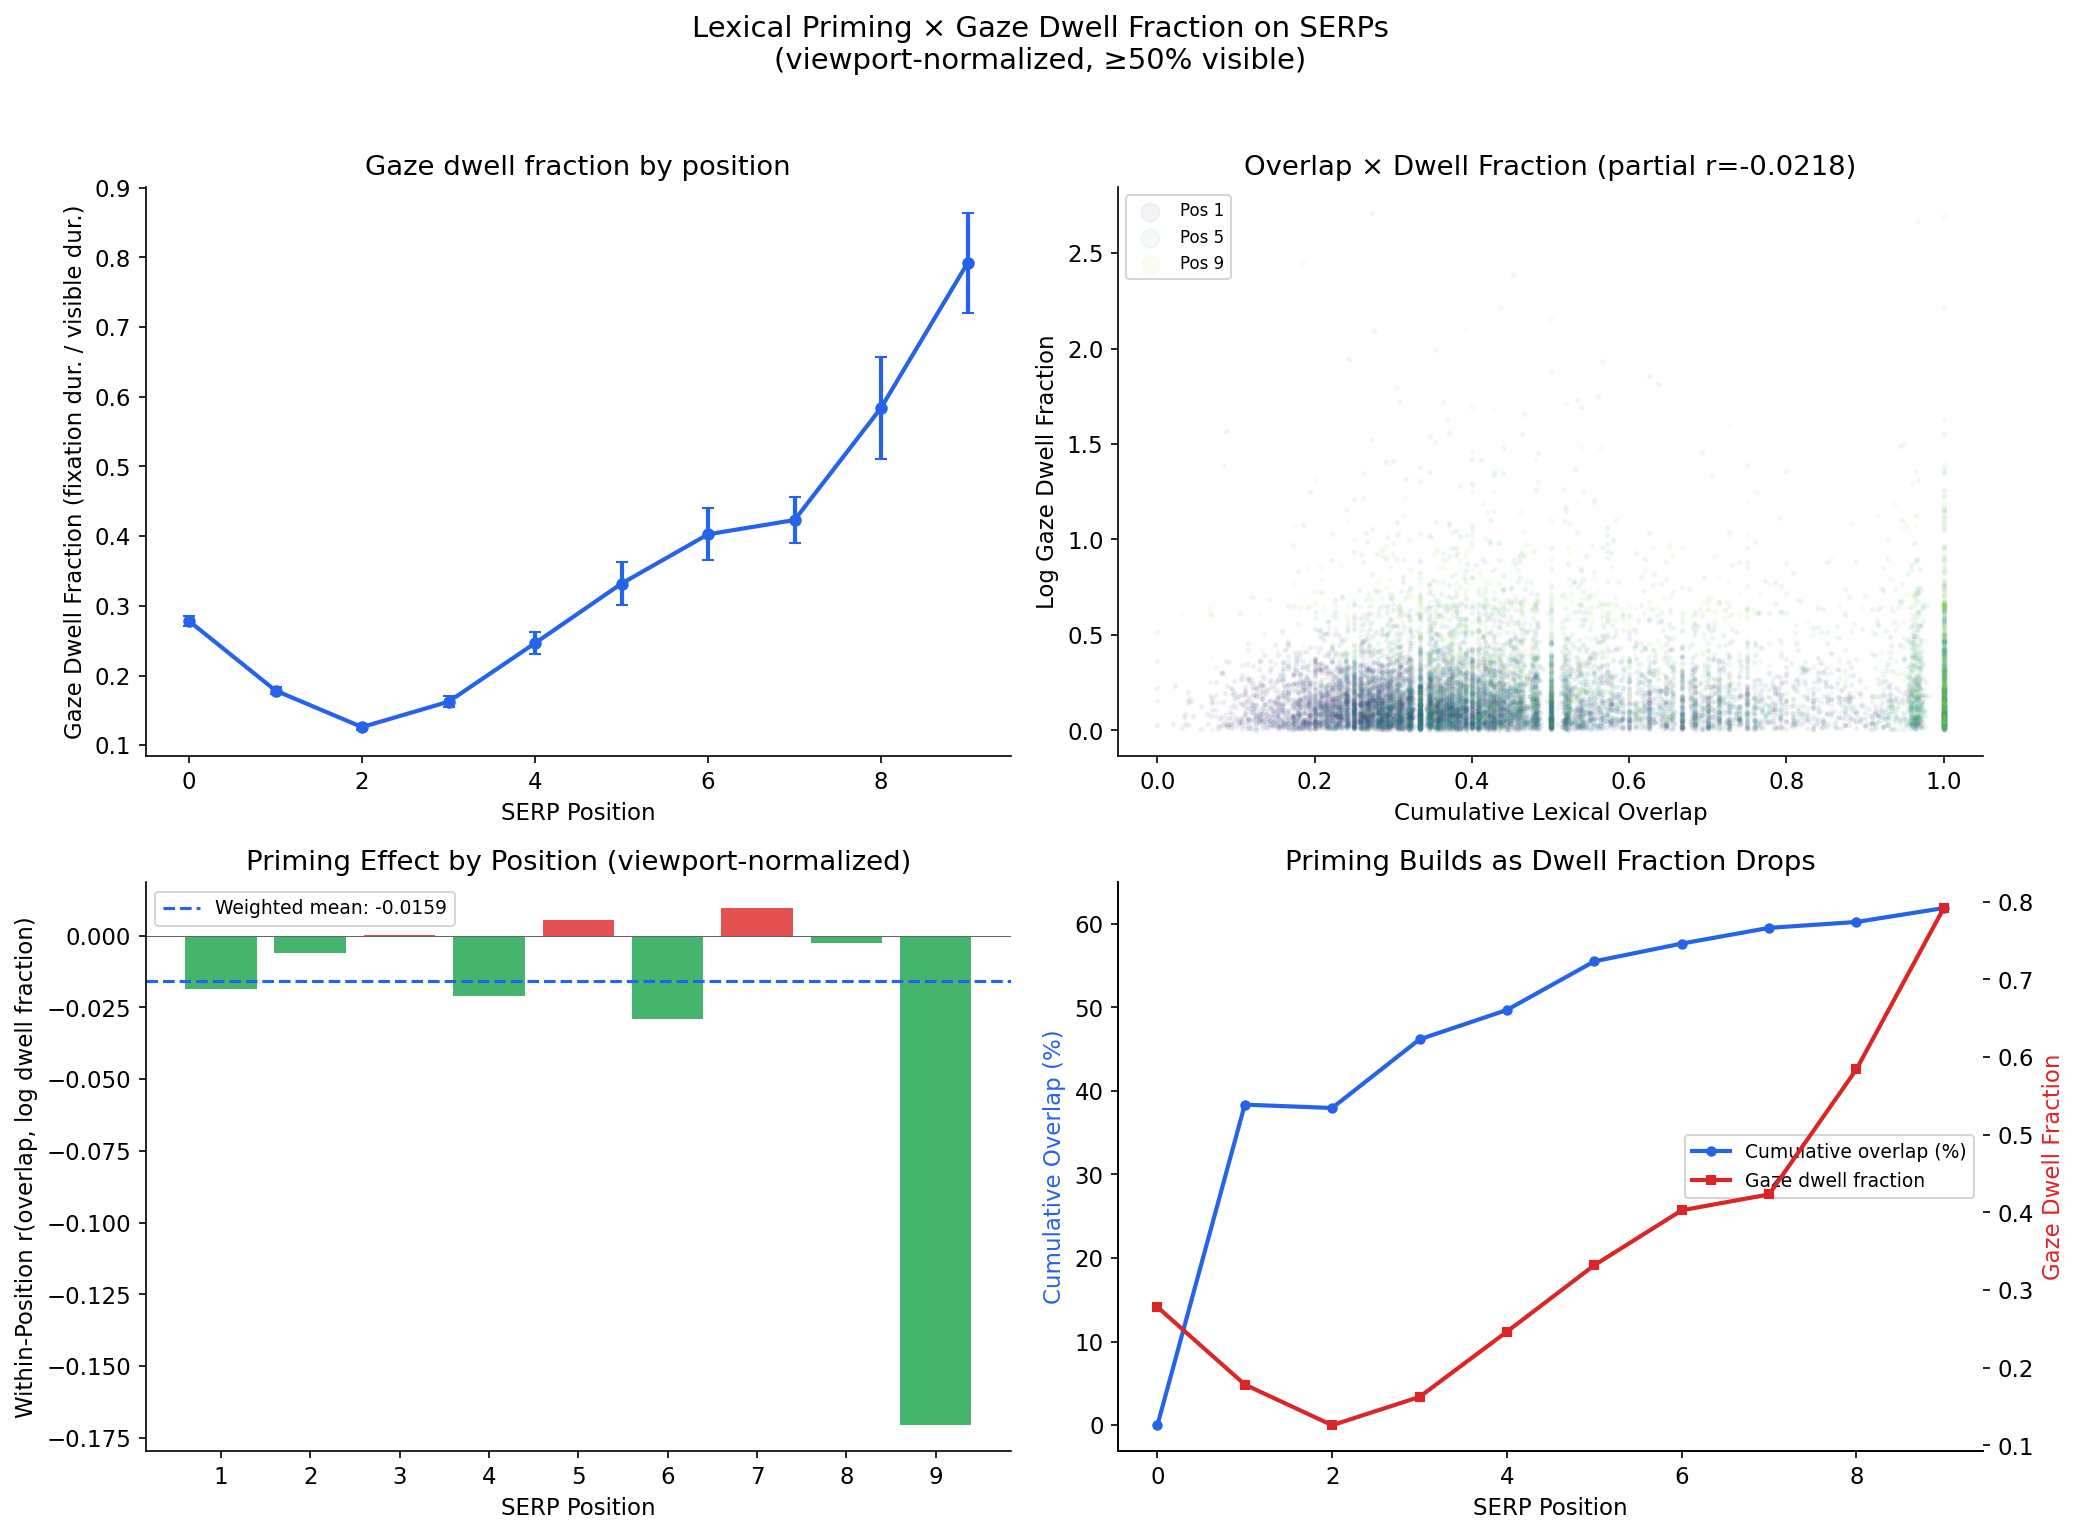

In [10]:
# ── Step 4c: Visualization ────────────────────────────────────────────────

# Build per-position aggregates from rows
fix_by_pos = defaultdict(list)
vp_by_pos = defaultdict(list)
eval_by_pos = defaultdict(list)
for r in rows:
    if r['position'] < 10:
        fix_by_pos[r['position']].append(r['fixation_ms'])
        vp_by_pos[r['position']].append(r['viewport_ms'])
        eval_by_pos[r['position']].append(r['eval_rate'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1: Mean gaze dwell fraction by position
ax = axes[0, 0]
pos_range = sorted(eval_by_pos.keys())
means_eval = [np.mean(eval_by_pos[p]) for p in pos_range]
sems_eval = [np.std(eval_by_pos[p]) / np.sqrt(len(eval_by_pos[p])) for p in pos_range]
ax.errorbar(pos_range, means_eval, yerr=[s*1.96 for s in sems_eval],
            color='#2563eb', linewidth=2, marker='o', markersize=5, capsize=3)
ax.set_xlabel('SERP Position')
ax.set_ylabel('Gaze Dwell Fraction (fixation dur. / visible dur.)')
ax.set_title('Gaze dwell fraction by position')
ax.set_xlim(-0.5, 9.5)

# 2: Overlap vs dwell fraction (scatter with position color)
ax = axes[0, 1]
cmap = plt.cm.viridis
for p in range(1, 10):
    mask = positions == p
    ax.scatter(overlaps[mask], log_eval[mask], alpha=0.05, s=3,
               color=cmap(p / 10), label=f'Pos {p}' if p in [1, 5, 9] else None)
ax.set_xlabel('Cumulative Lexical Overlap')
ax.set_ylabel('Log Gaze Dwell Fraction')
ax.set_title(f'Overlap × Dwell Fraction (partial r={r_part_eval:.4f})')
ax.legend(fontsize=8, markerscale=5)

# 3: Within-position r values (dwell fraction)
ax = axes[1, 0]
if within_rs:
    pos_labels = [str(p) for p in range(1, 1 + len(within_rs))]
    colors = ['#16a34a' if r < 0 else '#dc2626' for r in within_rs]
    ax.bar(pos_labels, within_rs, color=colors, alpha=0.8)
    ax.axhline(0, color='#666', linewidth=0.5)
    ax.axhline(wmean_r, color='#2563eb', linewidth=1.5, linestyle='--',
               label=f'Weighted mean: {wmean_r:.4f}')
    ax.set_xlabel('SERP Position')
    ax.set_ylabel('Within-Position r(overlap, log dwell fraction)')
    ax.set_title('Priming Effect by Position (viewport-normalized)')
    ax.legend(fontsize=9)

# 4: Dual axis — overlap curve + dwell fraction curve
ax = axes[1, 1]
ax_right = ax.twinx()
overlap_means = [np.mean(overlap_by_position[p]) * 100 for p in pos_range]
eval_means = [np.mean(eval_by_pos[p]) for p in pos_range]

l1 = ax.plot(pos_range, overlap_means, color='#2563eb', linewidth=2, marker='o',
             markersize=4, label='Cumulative overlap (%)')
l2 = ax_right.plot(pos_range, eval_means, color='#dc2626', linewidth=2, marker='s',
                   markersize=4, label='Gaze dwell fraction')
ax.set_xlabel('SERP Position')
ax.set_ylabel('Cumulative Overlap (%)', color='#2563eb')
ax_right.set_ylabel('Gaze Dwell Fraction', color='#dc2626')
ax.set_title('Priming Builds as Dwell Fraction Drops')
lines = l1 + l2
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, fontsize=9, loc='center right')

plt.suptitle('Lexical Priming × Gaze Dwell Fraction on SERPs\n(viewport-normalized, ≥50% visible)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plot_priming3_fixation.png', dpi=200, bbox_inches='tight')
plt.show()

Computing forward-only dwell fractions...


Forward-only observations: 14413 (vs 16330 total)
Skipped: 5

 Pos  Fwd Dwell  All Dwell  Fwd N  All N
   0      0.282      0.278   2718   2736
   1      0.180      0.178   2583   2634
   2      0.126      0.126   2245   2365
   3      0.176      0.162   1803   1985
   4      0.280      0.246   1464   1652
   5      0.366      0.332   1141   1351
   6      0.457      0.403    887   1093
   7      0.536      0.423    694    894
   8      0.698      0.584    499    738
   9      0.726      0.792    281    559

SHAPE TEST (forward-only, positions 0-8)
Spearman ρ (overlap means vs dwell means): 0.8167 (p=7.2248e-03)
Direction: CONTRA (positive)



Permutation test (10000 iterations):
  Observed ρ:  0.8167
  Perm mean ρ: 0.0516
  Perm SD:     0.3646
  p (one-tailed, ρ ≤ observed): 0.9912
  NOT SIGNIFICANT at α=0.05


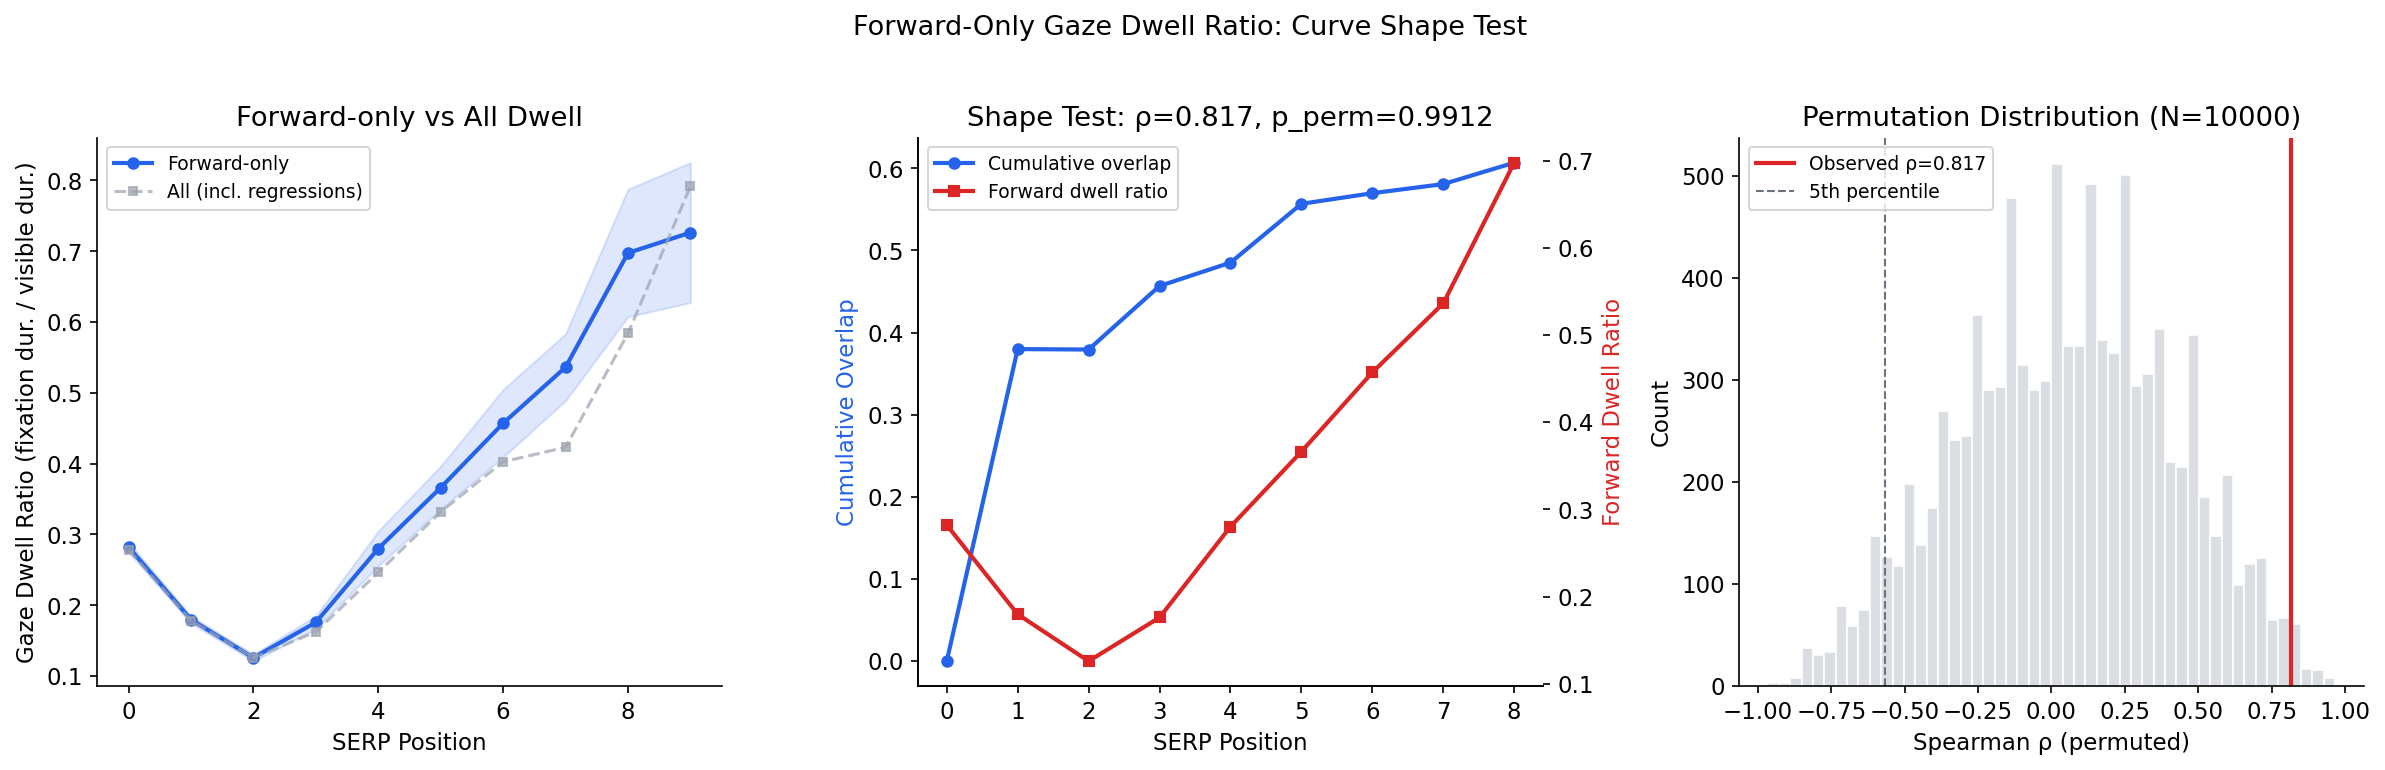

In [11]:
# ── Step 5: Forward-only dwell curve + shape test ─────────────────────────
#
# The per-position priming correlations (Step 4b) tested the wrong thing:
# individual position significance, conflating forward evaluation with
# regressive re-examination. Positions 8-9 showed the strongest "priming"
# but are also where regressions concentrate — lower dwell on revisit
# is memory, not priming.
#
# The real claim is about curve shape: does dwell fraction decline
# monotonically with cumulative overlap during FORWARD scanning?
#
# Approach:
#   1. Segment each trial into forward vs regressive scroll periods
#   2. Attribute fixations to forward-only periods
#   3. Compute forward-only dwell fraction per position
#   4. Test the shape: Spearman ρ of position-level means
#   5. Permutation test: is the observed monotonic decline unlikely by chance?

def classify_scroll_periods(trial_id):
    """Segment trial into forward and regressive time periods.
    
    Returns list of (t_start, t_end, scroll_y, direction) tuples.
    Direction is 'forward', 'regression', or 'static' (pre-scroll).
    """
    path = os.path.join(MOUSE_DIR, f'{trial_id}.csv')
    all_events = []
    scrolls = []
    
    with open(path) as f:
        for r in csv.DictReader(f):
            t = int(float(r['timestamp']))
            all_events.append(t)
            if r['event'] == 'scroll':
                scrolls.append((t, float(r['ypos'])))
    
    if not all_events:
        return None
    
    trial_start = min(all_events)
    trial_end = max(all_events)
    
    if not scrolls:
        # No scrolling — entire trial is static forward viewing
        return [(trial_start, trial_end, 0.0, 'forward')]
    
    # Segment into gestures (gaps > 200ms)
    gestures = []
    gesture = [scrolls[0]]
    for i in range(1, len(scrolls)):
        if scrolls[i][0] - scrolls[i-1][0] > 200:
            gestures.append(gesture)
            gesture = [scrolls[i]]
        else:
            gesture.append(scrolls[i])
    gestures.append(gesture)
    
    periods = []
    
    # Pre-scroll period: page load to first scroll — this is forward scanning
    if scrolls[0][0] > trial_start:
        periods.append((trial_start, scrolls[0][0], 0.0, 'forward'))
    
    # Classify each gesture
    prev_end_t = scrolls[0][0]
    for g in gestures:
        if len(g) < 2:
            # Single-event gesture: treat as continuation of previous state
            continue
        
        delta = g[-1][1] - g[0][1]
        direction = 'forward' if delta > 10 else ('regression' if delta < -10 else 'forward')
        
        # Gap between gestures: attribute to direction of next gesture
        # (user is pausing before scrolling — intent matches the gesture)
        if g[0][0] > prev_end_t:
            # Inter-gesture gap — use the scroll position at end of last gesture
            # Direction: forward if user hasn't started regressing yet
            periods.append((prev_end_t, g[0][0], g[0][1], direction))
        
        # The gesture itself: use scroll position at start
        # (viewport is near this position throughout the gesture)
        periods.append((g[0][0], g[-1][0], g[0][1], direction))
        prev_end_t = g[-1][0]
    
    # Post-last-scroll period
    if trial_end > prev_end_t:
        # After last scroll — could be either. Classify based on last gesture.
        last_dir = periods[-1][3] if periods else 'forward'
        periods.append((prev_end_t, trial_end, scrolls[-1][1], last_dir))
    
    return periods


def compute_forward_only_metrics(trial_id, n_results, doc_height, screen_height):
    """Compute dwell fraction using only forward-scanning periods.
    
    Returns {pos: {'fix_ms': float, 'vp_ms': float, 'dwell': float}} or None.
    """
    bands = result_bands(n_results, doc_height)
    tops = [b[0] for b in bands]
    periods = classify_scroll_periods(trial_id)
    if not periods:
        return None
    
    forward_periods = [(t0, t1, sy) for t0, t1, sy, d in periods if d == 'forward']
    if not forward_periods:
        return None
    
    # Forward viewport time per result
    fwd_vp = defaultdict(float)
    for t0, t1, sy in forward_periods:
        dt = t1 - t0
        if dt <= 0 or dt > 60000:
            continue
        vp_top, vp_bot = sy, sy + screen_height
        for pos, (r_top, r_bot) in enumerate(bands):
            r_height = r_bot - r_top
            vis = max(0, min(r_bot, vp_bot) - max(r_top, vp_top))
            if vis >= r_height * 0.5:
                fwd_vp[pos] += dt
    
    # Forward fixation time per result — only fixations during forward periods
    # Load scroll timeline for interpolation
    sts, sys_ = [], []
    with open(os.path.join(MOUSE_DIR, f'{trial_id}.csv')) as f:
        for r in csv.DictReader(f):
            if r['event'] == 'scroll':
                sts.append(int(float(r['timestamp'])))
                sys_.append(float(r['ypos']))
    
    fp = os.path.join(FIXATION_DIR, f'{trial_id}.csv')
    if not os.path.exists(fp):
        return None
    
    fwd_fix = defaultdict(float)
    with open(fp) as f:
        for row in csv.DictReader(f):
            try:
                ft = int(float(row['timestamp']))
                fy = float(row['FPOGY'])
                fd = float(row['FPOGD'])
            except:
                continue
            
            # Check if this fixation falls in a forward period
            in_forward = False
            for t0, t1, _ in forward_periods:
                if t0 <= ft <= t1:
                    in_forward = True
                    break
            if not in_forward:
                continue
            
            # Interpolate scroll offset
            so = 0.0
            if sts:
                if ft <= sts[0]: so = sys_[0]
                elif ft >= sts[-1]: so = sys_[-1]
                else:
                    idx = bisect_right(sts, ft) - 1
                    if idx < len(sts) - 1:
                        frac = (ft - sts[idx]) / max(sts[idx+1] - sts[idx], 1)
                        so = sys_[idx] + frac * (sys_[idx+1] - sys_[idx])
                    else:
                        so = sys_[-1]
            fy = max(0.0, min(fy, scr_h))  # clamp to screen bounds
            page_y = fy + so
            pos = bisect_right(tops, page_y) - 1
            if 0 <= pos < n_results:
                fwd_fix[pos] += fd
    
    result = {}
    for pos in range(n_results):
        fm = fwd_fix.get(pos, 0)
        vm = fwd_vp.get(pos, 0)
        if fm > 0 and vm > 100:
            result[pos] = {'fix_ms': fm, 'vp_ms': vm, 'dwell': fm / vm}
    
    return result if result else None


# ── Compute forward-only dwell fractions ──────────────────────────────────
print("Computing forward-only dwell fractions...")
fwd_rows = []
skipped = 0

for tid, data in serp_data.items():
    doc_h, scr_h = get_trial_meta(tid)
    if not doc_h or not scr_h:
        skipped += 1
        continue
    
    n = data['n_results']
    metrics = compute_forward_only_metrics(tid, n, doc_h, scr_h)
    if not metrics:
        skipped += 1
        continue
    
    for r in data['results']:
        p = r['position']
        if p in metrics:
            m = metrics[p]
            fwd_rows.append({
                'trial': tid,
                'position': p,
                'fixation_ms': m['fix_ms'],
                'viewport_ms': m['vp_ms'],
                'dwell': m['dwell'],
                'cumulative_overlap': r['cumulative_overlap'],
            })

print(f"Forward-only observations: {len(fwd_rows)} (vs {len(rows)} total)")
print(f"Skipped: {skipped}")

# ── Per-position means ────────────────────────────────────────────────────
fwd_by_pos = defaultdict(list)
for r in fwd_rows:
    if r['position'] < 10:
        fwd_by_pos[r['position']].append(r['dwell'])

fwd_positions = sorted(fwd_by_pos.keys())
fwd_means = [np.mean(fwd_by_pos[p]) for p in fwd_positions]
fwd_ns = [len(fwd_by_pos[p]) for p in fwd_positions]

print(f"\n{'Pos':>4} {'Fwd Dwell':>10} {'All Dwell':>10} {'Fwd N':>6} {'All N':>6}")
for p in fwd_positions:
    all_mean = np.mean([r['eval_rate'] for r in rows if r['position'] == p])
    print(f"{p:>4} {np.mean(fwd_by_pos[p]):>10.3f} {all_mean:>10.3f} "
          f"{len(fwd_by_pos[p]):>6} {len([r for r in rows if r['position'] == p]):>6}")

# ── Shape test: Spearman ρ on position means ──────────────────────────────
from scipy.stats import spearmanr

# Use positions 0-8 (exclude 9 which has viewport edge effects)
test_pos = [p for p in fwd_positions if p <= 8]
test_overlaps = [np.mean([r['cumulative_overlap'] for r in fwd_rows if r['position'] == p]) for p in test_pos]
test_dwells = [np.mean(fwd_by_pos[p]) for p in test_pos]

rho_obs, p_spearman = spearmanr(test_overlaps, test_dwells)
print(f"\n{'='*60}")
print(f"SHAPE TEST (forward-only, positions 0-8)")
print(f"{'='*60}")
print(f"Spearman ρ (overlap means vs dwell means): {rho_obs:.4f} (p={p_spearman:.4e})")
print(f"Direction: {'PRIMING (negative)' if rho_obs < 0 else 'CONTRA (positive)'}")

# ── Permutation test on the curve ─────────────────────────────────────────
# Null: shuffle overlap labels across positions, recompute Spearman ρ
# This tests whether the *shape* of overlap increasing while dwell decreases
# is unlikely under random position assignment.

n_perms = 10000
rng = np.random.default_rng(42)

# Pool all forward-only observations
fwd_overlaps = np.array([r['cumulative_overlap'] for r in fwd_rows if r['position'] <= 8])
fwd_dwells = np.array([r['dwell'] for r in fwd_rows if r['position'] <= 8])
fwd_pos = np.array([r['position'] for r in fwd_rows if r['position'] <= 8])

perm_rhos = np.zeros(n_perms)
for pi in range(n_perms):
    # Shuffle position labels, recompute position-level means
    shuffled_pos = rng.permutation(fwd_pos)
    shuf_overlap_means = [np.mean(fwd_overlaps[shuffled_pos == p]) for p in test_pos]
    shuf_dwell_means = [np.mean(fwd_dwells[shuffled_pos == p]) for p in test_pos]
    perm_rhos[pi], _ = spearmanr(shuf_overlap_means, shuf_dwell_means)

p_perm = np.mean(perm_rhos <= rho_obs)  # one-tailed: how often is permuted ρ as negative?
print(f"\nPermutation test ({n_perms} iterations):")
print(f"  Observed ρ:  {rho_obs:.4f}")
print(f"  Perm mean ρ: {np.mean(perm_rhos):.4f}")
print(f"  Perm SD:     {np.std(perm_rhos):.4f}")
print(f"  p (one-tailed, ρ ≤ observed): {p_perm:.4f}")
print(f"  {'SIGNIFICANT' if p_perm < 0.05 else 'NOT SIGNIFICANT'} at α=0.05")

# ── Visualization ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1: Forward-only dwell curve vs all-data curve
ax = axes[0]
all_means = [np.mean([r['eval_rate'] for r in rows if r['position'] == p]) for p in fwd_positions]
ax.plot(fwd_positions, fwd_means, color='#2563eb', linewidth=2, marker='o',
        markersize=5, label='Forward-only')
ax.plot(fwd_positions, all_means, color='#9ca3af', linewidth=1.5, marker='s',
        markersize=4, linestyle='--', label='All (incl. regressions)', alpha=0.7)
fwd_sems = [np.std(fwd_by_pos[p]) / np.sqrt(len(fwd_by_pos[p])) for p in fwd_positions]
ax.fill_between(fwd_positions,
                [m - 1.96*s for m, s in zip(fwd_means, fwd_sems)],
                [m + 1.96*s for m, s in zip(fwd_means, fwd_sems)],
                alpha=0.15, color='#2563eb')
ax.set_xlabel('SERP Position')
ax.set_ylabel('Gaze Dwell Ratio (fixation dur. / visible dur.)')
ax.set_title('Forward-only vs All Dwell')
ax.legend(fontsize=9)
ax.set_xlim(-0.5, 9.5)

# 2: Overlap vs forward dwell (dual axis, the shape test)
ax = axes[1]
ax2 = ax.twinx()
l1 = ax.plot(test_pos, test_overlaps, color='#2563eb', linewidth=2, marker='o',
             markersize=5, label='Cumulative overlap')
l2 = ax2.plot(test_pos, test_dwells, color='#dc2626', linewidth=2, marker='s',
              markersize=5, label='Forward dwell ratio')
ax.set_xlabel('SERP Position')
ax.set_ylabel('Cumulative Overlap', color='#2563eb')
ax2.set_ylabel('Forward Dwell Ratio', color='#dc2626')
ax.set_title(f'Shape Test: ρ={rho_obs:.3f}, p_perm={p_perm:.4f}')
lines = l1 + l2
ax.legend(lines, [l.get_label() for l in lines], fontsize=9)

# 3: Permutation distribution
ax = axes[2]
ax.hist(perm_rhos, bins=50, color='#d1d5db', edgecolor='white', alpha=0.8)
ax.axvline(rho_obs, color='#dc2626', linewidth=2, label=f'Observed ρ={rho_obs:.3f}')
ax.axvline(np.percentile(perm_rhos, 5), color='#6b7280', linewidth=1, linestyle='--',
           label='5th percentile')
ax.set_xlabel('Spearman ρ (permuted)')
ax.set_ylabel('Count')
ax.set_title(f'Permutation Distribution (N={n_perms})')
ax.legend(fontsize=9)

plt.suptitle('Forward-Only Gaze Dwell Ratio: Curve Shape Test',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plot_priming4_forward_shape.png', dpi=200, bbox_inches='tight')
plt.show()


In [12]:
# ── Step 6: p(fixate | visible) — does overlap predict skipping? ──────────
#
# Steps 4-5 analyzed dwell ratio CONDITIONAL on fixation (fm > 0).
# This excludes the strongest possible priming signal: results that were
# visible but never fixated — skipped entirely. If priming causes skipping,
# p(fixate) should decline with overlap.

from scipy.stats import chi2_contingency

print("Computing p(fixate | visible) per result per trial...")

# Build full dataset including zero-fixation results
all_vis_rows = []
skipped = 0

for tid, data in serp_data.items():
    doc_h, scr_h = get_trial_meta(tid)
    if not doc_h or not scr_h:
        skipped += 1
        continue

    n = data['n_results']
    vp_time = compute_viewport_time(tid, n, doc_h, scr_h)
    fix_time = compute_fixation_per_result(tid, n, doc_h)
    if not vp_time:
        skipped += 1
        continue
    if not fix_time:
        fix_time = {}  # no fixation file — all zeros

    for r in data['results']:
        p = r['position']
        vm = vp_time.get(p, 0)
        if vm < 100:  # must have been visible ≥100ms
            continue
        fm = fix_time.get(p, 0)
        all_vis_rows.append({
            'trial': tid,
            'position': p,
            'fixated': 1 if fm > 0 else 0,
            'fixation_ms': fm,
            'viewport_ms': vm,
            'cumulative_overlap': r['cumulative_overlap'],
        })

n_vis = len(all_vis_rows)
n_fix = sum(r['fixated'] for r in all_vis_rows)
n_skip = n_vis - n_fix
print(f"Visible results: {n_vis}")
print(f"  Fixated: {n_fix} ({n_fix/n_vis*100:.1f}%)")
print(f"  Skipped: {n_skip} ({n_skip/n_vis*100:.1f}%)")

# ── Per-position p(fixate) ────────────────────────────────────────────────
print(f"\n{'Pos':>4} {'p(fix)':>8} {'N_vis':>6} {'N_fix':>6} {'N_skip':>6} {'Overlap':>8}")
pfix_by_pos = {}
for p in range(10):
    sub = [r for r in all_vis_rows if r['position'] == p]
    if not sub:
        continue
    nf = sum(r['fixated'] for r in sub)
    pfix_by_pos[p] = nf / len(sub)
    mean_ov = np.mean([r['cumulative_overlap'] for r in sub])
    print(f"{p:>4} {nf/len(sub):>8.3f} {len(sub):>6} {nf:>6} {len(sub)-nf:>6} {mean_ov:>7.1%}")

# ── Aggregate: does overlap predict p(fixate)? ───────────────────────────
from scipy.stats import pointbiserialr

vis_1_9 = [r for r in all_vis_rows if 1 <= r['position'] <= 9]
overlaps_all = np.array([r['cumulative_overlap'] for r in vis_1_9])
fixated_all = np.array([r['fixated'] for r in vis_1_9])
positions_all = np.array([r['position'] for r in vis_1_9])

r_agg, p_agg = pointbiserialr(fixated_all, overlaps_all)
print(f"\nAggregate point-biserial r (fixated × overlap): {r_agg:.4f} (p={p_agg:.2e})")

# ── Within-position: at same rank, does overlap predict fixation? ─────────
print(f"\n{'Pos':>4} {'r_pb':>8} {'p':>12} {'N':>6} {'Direction':>12}")
within_rs_pf = []
within_ns_pf = []
for p in range(1, 10):
    sub = [r for r in vis_1_9 if r['position'] == p]
    if len(sub) < 30:
        continue
    ov = np.array([r['cumulative_overlap'] for r in sub])
    fx = np.array([r['fixated'] for r in sub])
    if np.std(ov) < 0.01 or fx.sum() == 0 or fx.sum() == len(fx):
        continue
    rw, pw = pointbiserialr(fx, ov)
    d = 'SKIP↑' if rw < 0 else 'FIX↑'
    print(f"{p:>4} {rw:>8.4f} {pw:>12.2e} {len(sub):>6} {d:>12}")
    within_rs_pf.append(rw)
    within_ns_pf.append(len(sub))

if within_rs_pf:
    wmean = np.average(within_rs_pf, weights=within_ns_pf)
    n_neg = sum(1 for r in within_rs_pf if r < 0)
    print(f"\n   Weighted mean r_pb: {wmean:.4f}")
    print(f"   Sign consistency: {n_neg}/{len(within_rs_pf)} negative (skip direction)")

# ── Median split per position ─────────────────────────────────────────────
print(f"\nMedian-split p(fixate) by overlap, within position:")
print(f"{'Pos':>4} {'p(fix) low':>11} {'p(fix) high':>12} {'Δ':>8} {'χ²_p':>10}")
for p in range(1, 10):
    sub = [r for r in vis_1_9 if r['position'] == p]
    if len(sub) < 30:
        continue
    ov = np.array([r['cumulative_overlap'] for r in sub])
    fx = np.array([r['fixated'] for r in sub])
    med = np.median(ov)
    lo = fx[ov <= med]
    hi = fx[ov > med]
    if len(lo) < 10 or len(hi) < 10:
        continue
    pf_lo = lo.mean()
    pf_hi = hi.mean()
    # Chi-squared test
    table = np.array([[lo.sum(), len(lo) - lo.sum()],
                      [hi.sum(), len(hi) - hi.sum()]])
    if table.min() >= 0:
        chi2, chi_p, _, _ = chi2_contingency(table)
    else:
        chi_p = 1.0
    print(f"{p:>4} {pf_lo:>11.3f} {pf_hi:>12.3f} {pf_hi - pf_lo:>+8.3f} {chi_p:>10.4f}")

# ── Forward-only p(fixate) ────────────────────────────────────────────────
print(f"\n--- Forward-only p(fixate) ---")
fwd_vis_rows = []
for tid, data in serp_data.items():
    doc_h, scr_h = get_trial_meta(tid)
    if not doc_h or not scr_h:
        continue
    n = data['n_results']
    metrics = compute_forward_only_metrics(tid, n, doc_h, scr_h)
    vp_time = compute_viewport_time(tid, n, doc_h, scr_h)
    if not vp_time:
        continue

    # For forward-only: a result is "forward-visible" if it has forward viewport time
    # and "forward-fixated" if it has forward fixation time
    if not metrics:
        # No forward data — use viewport time to mark visible, all unfixated
        for r in data['results']:
            p = r['position']
            vm = vp_time.get(p, 0)
            if vm >= 100:
                fwd_vis_rows.append({
                    'position': p,
                    'fixated': 0,
                    'cumulative_overlap': r['cumulative_overlap'],
                })
        continue

    for r in data['results']:
        p = r['position']
        if p in metrics and metrics[p]['vp_ms'] >= 100:
            fwd_vis_rows.append({
                'position': p,
                'fixated': 1 if metrics[p]['fix_ms'] > 0 else 0,
                'cumulative_overlap': r['cumulative_overlap'],
            })

fwd_1_9 = [r for r in fwd_vis_rows if 1 <= r['position'] <= 9]
print(f"Forward-visible results (pos 1-9): {len(fwd_1_9)}")
fwd_ov = np.array([r['cumulative_overlap'] for r in fwd_1_9])
fwd_fx = np.array([r['fixated'] for r in fwd_1_9])
fwd_pos = np.array([r['position'] for r in fwd_1_9])

r_fwd, p_fwd = pointbiserialr(fwd_fx, fwd_ov)
print(f"Forward-only point-biserial r: {r_fwd:.4f} (p={p_fwd:.2e})")

# Within-position for forward-only
print(f"\n{'Pos':>4} {'r_pb':>8} {'p':>12} {'N':>6} {'p(fix)':>8}")
fwd_within = []
fwd_within_n = []
for p in range(1, 10):
    mask = fwd_pos == p
    if mask.sum() < 30:
        continue
    ov = fwd_ov[mask]
    fx = fwd_fx[mask]
    if np.std(ov) < 0.01 or fx.sum() == 0 or fx.sum() == len(fx):
        print(f"{p:>4} {'---':>8} {'---':>12} {mask.sum():>6} {fx.mean():>8.3f}")
        continue
    rw, pw = pointbiserialr(fx, ov)
    print(f"{p:>4} {rw:>8.4f} {pw:>12.2e} {mask.sum():>6} {fx.mean():>8.3f}")
    fwd_within.append(rw)
    fwd_within_n.append(mask.sum())

if fwd_within:
    wmean_fwd = np.average(fwd_within, weights=fwd_within_n)
    n_neg_fwd = sum(1 for r in fwd_within if r < 0)
    print(f"\n   Forward-only weighted mean r_pb: {wmean_fwd:.4f}")
    print(f"   Sign consistency: {n_neg_fwd}/{len(fwd_within)} negative (skip direction)")

# ── Summary ───────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("SUMMARY: p(fixate | visible)")
print(f"{'='*60}")
print(f"Skipped results (visible, zero fixation): {n_skip}/{n_vis} ({n_skip/n_vis*100:.1f}%)")
print(f"Aggregate r_pb (overlap × fixated):       {r_agg:.4f} (p={p_agg:.2e})")
if within_rs_pf:
    print(f"Within-position weighted mean r_pb:       {wmean:.4f}")
    print(f"Within-position sign consistency:         {n_neg}/{len(within_rs_pf)} skip direction")
print(f"Forward-only r_pb:                        {r_fwd:.4f} (p={p_fwd:.2e})")
if fwd_within:
    print(f"Forward-only within-position mean r_pb:  {wmean_fwd:.4f}")
    print(f"Forward-only sign consistency:           {n_neg_fwd}/{len(fwd_within)} skip direction")


Computing p(fixate | visible) per result per trial...


Visible results: 18299
  Fixated: 16330 (89.2%)
  Skipped: 1969 (10.8%)

 Pos   p(fix)  N_vis  N_fix N_skip  Overlap
   0    0.987   2772   2736     36    0.0%
   1    0.950   2772   2634    138   38.4%
   2    0.858   2755   2365    390   38.0%
   3    0.823   2412   1985    427   45.9%
   4    0.846   1952   1652    300   48.7%
   5    0.875   1544   1351    193   55.3%
   6    0.872   1254   1093    161   56.5%
   7    0.870   1027    894    133   58.1%
   8    0.865    853    738    115   58.8%
   9    0.905    618    559     59   60.3%

Aggregate point-biserial r (fixated × overlap): -0.0189 (p=2.00e-02)

 Pos     r_pb            p      N    Direction
   1  -0.0588     1.94e-03   2772        SKIP↑
   2  -0.0054     7.78e-01   2755        SKIP↑
   3  -0.0050     8.08e-01   2412        SKIP↑
   4  -0.0070     7.58e-01   1952        SKIP↑
   5   0.0210     4.09e-01   1544         FIX↑
   6   0.0080     7.77e-01   1254         FIX↑
   7   0.0307     3.26e-01   1027         FIX↑
   8  

Forward-visible results (pos 1-9): 11618
Forward-only point-biserial r: 0.0031 (p=7.35e-01)

 Pos     r_pb            p      N   p(fix)
   1  -0.0400     4.17e-02   2588    0.998
   2   0.0007     9.73e-01   2250    0.998
   3  -0.0006     9.80e-01   1807    0.998
   4   0.0327     2.11e-01   1466    0.999
   5   0.0203     4.93e-01   1142    0.999
   6   0.0330     3.27e-01    888    0.999
   7   0.0087     8.18e-01    695    0.999
   8  -0.0557     2.14e-01    500    0.998
   9   0.0994     9.58e-02    282    0.996

   Forward-only weighted mean r_pb: 0.0003
   Sign consistency: 3/9 negative (skip direction)

SUMMARY: p(fixate | visible)
Skipped results (visible, zero fixation): 1969/18299 (10.8%)
Aggregate r_pb (overlap × fixated):       -0.0189 (p=2.00e-02)
Within-position weighted mean r_pb:       -0.0137
Within-position sign consistency:         6/9 skip direction
Forward-only r_pb:                        0.0031 (p=7.35e-01)
Forward-only within-position mean r_pb:  0.0003
Forward